## New Complete Solution

Feature extraction

In [ ]:
## Feature Extraction
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Custom transformer to extract time-domain features from EMG windows.
    Inherits from scikit-learn's BaseEstimator and TransformerMixin.
    """
    
    def __init__(self, selected_features=None):
        """
        Initialize the feature extractor.
        
        Parameters:
        -----------
        selected_features : list or None
            List of feature indices to select. If None, all features are used.
        """
        self.selected_features = selected_features
        
        # Define all available features
        self.all_features = ['MAV', 'RMS', 'VAR', 'STD', 'ZC', 'MPR', 'SSC', 'WL']
        
        # Always use all features for extraction, then select if needed
        self.feature_names = self.all_features
        self.selected_electrodes = list(range(8))  # All 8 electrodes
    
    def fit(self, X, y=None):
        """
        Fit method (does nothing but needed for scikit-learn pipeline compatibility).
        """
        return self
    
    def transform(self, X):
        """
        Extract features from EMG windows.
        
        Parameters:
        -----------
        X : numpy.ndarray
            Input data with shape (n_samples, n_channels, window_size)
            
        Returns:
        --------
        features : numpy.ndarray
            Extracted features with shape (n_samples, n_features)
        """
        n_samples, n_channels, window_size = X.shape
        
        # Regular feature extraction for all features
        n_features = len(self.feature_names) * len(self.selected_electrodes)
        features = np.zeros((n_samples, n_features))
        
        for i in range(n_samples):
            sample_features = self._extract_features_from_window(X[i])
            features[i] = sample_features
        
        # Apply feature selection if provided
        if self.selected_features is not None:
            features = features[:, self.selected_features]
        
        return features
    
    def _extract_features_from_window(self, window):
        """
        Extract features from a single EMG window.
        """
        features = []
        
        for channel in self.selected_electrodes:
            channel_data = window[channel]
            channel_features = []
            
            # Mean Absolute Value (MAV)
            if 'MAV' in self.feature_names:
                mav = np.mean(np.abs(channel_data))
                channel_features.append(mav)
            
            # Root Mean Square (RMS)
            if 'RMS' in self.feature_names:
                rms = np.sqrt(np.mean(channel_data**2))
                channel_features.append(rms)
            
            # Variance (VAR)
            if 'VAR' in self.feature_names:
                var = np.var(channel_data)
                channel_features.append(var)
            
            # Standard Deviation (STD)
            if 'STD' in self.feature_names:
                std = np.std(channel_data)
                channel_features.append(std)
            
            # Zero Crossing (ZC)
            if 'ZC' in self.feature_names:
                zc = np.sum(np.diff(np.signbit(channel_data).astype(int)) != 0)
                channel_features.append(zc)
            
            # Myopulse Percentage Rate (MPR)
            if 'MPR' in self.feature_names:
                threshold = np.std(channel_data)
                mpr = np.mean(np.abs(channel_data) > threshold)
                channel_features.append(mpr)
                
            # Slope Sign Changes (SSC)
            if 'SSC' in self.feature_names:
                diff1 = np.diff(channel_data)
                diff2 = np.diff(channel_data, n=2)
                ssc = np.sum((diff1[:-1] * diff2) > 0)
                channel_features.append(ssc)
                
            # Waveform Length (WL)
            if 'WL' in self.feature_names:
                wl = np.sum(np.abs(np.diff(channel_data)))
                channel_features.append(wl)
            
            # Add all features for this channel
            features.extend(channel_features)
        
        return np.array(features)
    
    def get_feature_names(self):
        """
        Get the names of the features that will be extracted.
        """
        feature_names = []
        for channel in self.selected_electrodes:
            for feature in self.feature_names:
                feature_names.append(f'E{channel+1}_{feature}')
        
        if self.selected_features is not None:
            # Return only the selected feature names
            return [feature_names[i] for i in self.selected_features]
        
        return feature_names

In [ ]:
def calculate_metrics(y_true, y_pred):
    """
    Calculate regression metrics for multi-dimensional outputs.
    
    Parameters:
    -----------
    y_true : numpy.ndarray
        True joint angles with shape (n_samples, n_joints)
    y_pred : numpy.ndarray
        Predicted joint angles with shape (n_samples, n_joints)
    
    Returns:
    --------
    metrics : dict
        Dictionary containing RMSE and NMSE values
    """
    import numpy as np
    
    n_samples, n_joints = y_true.shape
    
    # Calculate RMSE
    squared_errors = (y_true - y_pred) ** 2
    rmse = np.sqrt(np.mean(squared_errors))
    
    # Calculate NMSE (Normalized Mean Squared Error)
    # NMSE = sum((y_true - y_pred)²) / sum((y_true - mean(y_true))²)
    y_mean = np.mean(y_true, axis=0)  # Mean for each joint angle
    numerator = np.sum(squared_errors)
    denominator = np.sum((y_true - y_mean) ** 2)
    nmse = numerator / denominator if denominator != 0 else float('inf')
    
    return {
        'rmse': rmse,
        'nmse': nmse
    }

def visualize_metrics_comparison(model_results, metric_name='rmse'):
    """
    Create a visualization comparing model performance based on specified metric.
    
    Parameters:
    -----------
    model_results : dict
        Dictionary with model names as keys and metrics as values
    metric_name : str
        Metric to visualize ('rmse' or 'nmse')
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Extract model names and metric values
    models = list(model_results.keys())
    metrics = [model_results[model][metric_name] for model in models]
    
    # Create figure
    plt.figure(figsize=(12, 6))
    
    # Plot bars
    bars = plt.bar(range(len(models)), metrics, width=0.6)
    
    # Add value labels on top of each bar
    for i, (bar, val) in enumerate(zip(bars, metrics)):
        plt.text(i, val + max(metrics)*0.01, f"{val:.4f}", ha='center')
    
    # Add labels and title
    plt.xlabel('Model')
    plt.ylabel(f'{metric_name.upper()}')
    plt.title(f'Model Performance Comparison ({metric_name.upper()})')
    plt.xticks(range(len(models)), models, rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Tight layout to ensure labels fit
    plt.tight_layout()
    
    # Save the figure
    plt.savefig(f'model_comparison_{metric_name}.png', dpi=300)
    plt.show()

Data Preprocessing & Signal filtering

In [ ]:
def preprocess_emg_data(X_data, apply_filtering=True, normalize=True, visualize=False,
                     session_id=0, electrode_id=0, time_segment=slice(0, 5000)):
    """
    Preprocess EMG data by applying filtering and normalization
    
    Parameters:
    -----------
    X_data : numpy.ndarray
        Input EMG data with shape (session, electrode, time) or 
        (n_windows, electrode, window_size)
    apply_filtering : bool
        Whether to apply bandpass and notch filtering to the signals
    normalize : bool
        Whether to normalize each channel to zero mean and unit variance
    visualize : bool
        Whether to visualize the original and filtered signals
    session_id : int
        Session ID to visualize (if visualize=True)
    electrode_id : int
        Electrode ID to visualize (if visualize=True)
    time_segment : slice
        Time segment to visualize (if visualize=True)
        
    Returns:
    --------
    processed_data : numpy.ndarray
        Preprocessed EMG data with the same shape as input
    """
    import numpy as np
    from scipy.signal import butter, filtfilt, iirnotch
    import matplotlib.pyplot as plt
    
    # Store the original shape to reshape at the end
    original_shape = X_data.shape
    original_data = X_data.copy()  # Keep a copy for visualization
    
    # Handle different input shapes
    if len(original_shape) == 3:
        if original_shape[0] <= 10:  # Likely (session, electrode, time)
            n_sessions, n_electrodes, n_samples = original_shape
            data_to_process = X_data.copy()
        else:  # Likely (n_windows, electrode, window_size)
            n_windows, n_electrodes, window_size = original_shape
            # Reshape to 3D for consistent processing
            data_to_process = X_data.reshape(1, n_electrodes, -1)
            n_sessions = 1
    elif len(original_shape) == 4:  # (session, window, electrode, time)
        n_sessions, n_windows, n_electrodes, window_size = original_shape
        # Reshape to 3D for processing
        data_to_process = X_data.reshape(n_sessions, n_electrodes, -1)
    else:
        raise ValueError(f"Unexpected input shape: {original_shape}")
    
    # Initialize the output array
    processed_data = np.zeros_like(data_to_process)
    
    # Apply filtering if requested
    if apply_filtering:
        print("Applying bandpass and notch filters to EMG signals...")
        # EMG bandpass filter settings (20-450 Hz)
        fs = 1024  # Sampling frequency in Hz
        lowcut = 20  # High-pass to remove motion artifacts
        highcut = 450  # Low-pass to remove high frequency noise or 500
        
        # Notch filter at 50Hz to remove power line interference
        notch_freq = 50
        quality_factor = 30  # Q factor determines notch width
        
        # Create bandpass filter
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b_band, a_band = butter(4, [low, high], btype='band')
        
        # Create notch filter
        b_notch, a_notch = iirnotch(notch_freq, quality_factor, fs)
        
        # Apply filters to each session and electrode
        for session in range(n_sessions):
            for electrode in range(n_electrodes):
                # First apply bandpass
                temp = filtfilt(b_band, a_band, data_to_process[session, electrode, :])
                # Then apply notch
                processed_data[session, electrode, :] = filtfilt(b_notch, a_notch, temp)
    else:
        processed_data = data_to_process.copy()
    
    # Check for and handle NaN or infinity values
    if np.any(~np.isfinite(processed_data)):
        print("Warning: NaN or infinity values detected in the data. Replacing with zeros.")
        processed_data[~np.isfinite(processed_data)] = 0
    
    # Normalize each channel if requested
    if normalize:
        print("Normalizing EMG channels...")
        for session in range(n_sessions):
            for electrode in range(n_electrodes):
                channel_data = processed_data[session, electrode, :]
                # Z-score normalization (zero mean, unit variance)
                mean = np.mean(channel_data)
                std = np.std(channel_data)
                if std > 0:  # Avoid division by zero
                    processed_data[session, electrode, :] = (channel_data - mean) / std
    
    # Visualize if requested
    if visualize and n_sessions > session_id and n_electrodes > electrode_id:
        visualize_filtered_signals(data_to_process, processed_data, session_id, electrode_id, time_segment)
    
    # Reshape back to the original shape
    if len(original_shape) == 3:
        if original_shape[0] <= 10:  # (session, electrode, time)
            return processed_data
        else:  # (n_windows, electrode, window_size)
            return processed_data.reshape(original_shape)
    elif len(original_shape) == 4:  # (session, window, electrode, time)
        return processed_data.reshape(original_shape)
    
    return processed_data


def visualize_filtered_signals(original_data, filtered_data, session_id=0, electrode_id=0, time_segment=slice(0, 5000)):
    """
    Visualize the original and filtered EMG signals.
    
    Parameters:
    -----------
    original_data : numpy.ndarray
        Original EMG data with shape (session, electrode, time)
    filtered_data : numpy.ndarray
        Filtered EMG data with shape (session, electrode, time)
    session_id : int
        Session ID to visualize
    electrode_id : int
        Electrode ID to visualize
    time_segment : slice
        Time segment to visualize
    """
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(15, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(original_data[session_id, electrode_id, time_segment])
    plt.title(f'Original EMG Signal - Session {session_id+1}, Electrode {electrode_id+1}')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.plot(filtered_data[session_id, electrode_id, time_segment])
    plt.title(f'Filtered EMG Signal - Session {session_id+1}, Electrode {electrode_id+1}')
    plt.xlabel('Time (samples)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def check_emg_data_quality(X_data):
    """
    Check the quality of EMG data and provide statistics
    
    Parameters:
    -----------
    X_data : numpy.ndarray
        Input EMG data
        
    Returns:
    --------
    quality_report : dict
        Dictionary containing quality metrics
    """
    import numpy as np
    
    quality_report = {}
    
    # Check for NaN or infinity values
    nan_count = np.sum(np.isnan(X_data))
    inf_count = np.sum(np.isinf(X_data))
    quality_report['nan_count'] = nan_count
    quality_report['inf_count'] = inf_count
    
    # Calculate basic statistics for each electrode
    if len(X_data.shape) == 3:  # (session, electrode, time) or (n_windows, electrode, window_size)
        n_sessions_or_windows, n_electrodes, _ = X_data.shape
        
        electrode_stats = []
        for electrode in range(n_electrodes):
            # Concatenate data across sessions/windows for this electrode
            electrode_data = X_data[:, electrode, :].flatten()
            
            stats = {
                'electrode': electrode + 1,
                'mean': np.mean(electrode_data),
                'std': np.std(electrode_data),
                'min': np.min(electrode_data),
                'max': np.max(electrode_data),
                'dynamic_range': np.max(electrode_data) - np.min(electrode_data),
                'signal_to_noise': np.mean(np.abs(electrode_data)) / np.std(electrode_data) if np.std(electrode_data) > 0 else 0
            }
            electrode_stats.append(stats)
        
        quality_report['electrode_stats'] = electrode_stats
    
    # Overall assessment
    quality_report['has_missing_values'] = nan_count > 0
    quality_report['has_infinite_values'] = inf_count > 0
    
    return quality_report

Windows creation

In [ ]:
def create_windows_with_overlap(data, window_size=500, overlap_percent=50):
    """
    Create overlapping windows from continuous EMG data with explicit verification
    of window positioning.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Input data with shape (session, electrode/joint, time)
    window_size : int
        Size of each window in samples (default: 500)
    overlap_percent : float
        Percentage of overlap between consecutive windows (0-100) (default: 50)
    
    Returns:
    --------
    windows : numpy.ndarray
        Windowed data with shape (n_windows_total, electrode/joint, window_size)
    window_indices : list of tuples
        List containing (session_idx, window_start_idx, window_end_idx) for each window
    """
    n_sessions, n_channels, n_samples = data.shape
    
    # Calculate step size based on overlap percentage
    step_size = int(window_size * (1 - overlap_percent/100))
    print(f"Window size: {window_size}, Overlap: {overlap_percent}%, Step size: {step_size}")
    
    windows = []
    window_indices = []
    
    # Process each session separately
    for session_idx in range(n_sessions):
        # Calculate how many windows we can extract from this session
        n_windows = 1 + (n_samples - window_size) // step_size
        
        for window_idx in range(n_windows):
            # Calculate start and end indices
            start_idx = window_idx * step_size
            end_idx = start_idx + window_size
            
            # Make sure we don't exceed the data length
            if end_idx <= n_samples:
                # Extract window for all channels
                window = data[session_idx, :, start_idx:end_idx]
                windows.append(window)
                window_indices.append((session_idx, start_idx, end_idx))
    
    # Convert list of windows to numpy array
    windows = np.array(windows)
    
    # Print out the first few window indices to verify correct overlap
    if len(window_indices) > 3:
        print("First few window indices to verify 50% overlap:")
        for i in range(min(5, len(window_indices))):
            session, start, end = window_indices[i]
            print(f"Window {i+1}: Session {session+1}, Samples {start+1}-{end}")
    
    return windows, window_indices

def create_matching_windows(X_data, y_data, window_size=500, overlap_percent=50):
    """
    Create matching windowed datasets for both EMG (X) and joint angles (y).
    
    Parameters:
    -----------
    X_data : numpy.ndarray
        EMG data with shape (session, electrode, time)
    y_data : numpy.ndarray
        Joint angle data with shape (session, joint, time)
    window_size : int
        Size of each window in samples
    overlap_percent : float
        Percentage of overlap between consecutive windows (0-100)
    
    Returns:
    --------
    X_windows : numpy.ndarray
        Windowed EMG data with shape (n_windows, electrode, window_size)
    y_windows : numpy.ndarray
        Windowed joint angle data with shape (n_windows, joint, window_size)
    window_indices : list of tuples
        List containing (session_idx, window_start_idx, window_end_idx) for each window
    """
    # Create windows for EMG data
    X_windows, window_indices = create_windows_with_overlap(X_data, window_size, overlap_percent)
    
    # Create matching windows for joint angle data using the same indices
    n_sessions, n_joints, _ = y_data.shape
    y_windows = []
    
    for session_idx, start_idx, end_idx in window_indices:
        window = y_data[session_idx, :, start_idx:end_idx]
        y_windows.append(window)
    
    y_windows = np.array(y_windows)
    
    return X_windows, y_windows, window_indices

Cross validation strategy

In [ ]:
def leave_one_session_out_cv(window_indices, n_sessions=5):
    """
    Create cross-validation splits based on leave-one-session-out strategy.
    
    Parameters:
    -----------
    window_indices : list of tuples
        List containing (session_idx, window_start_idx, window_end_idx) for each window
    n_sessions : int
        Number of sessions in the dataset
    
    Returns:
    --------
    cv_splits : list of tuples
        List of (train_idx, test_idx) tuples for cross-validation
    """
    # Extract session indices for each window
    session_indices = np.array([idx[0] for idx in window_indices])
    cv_splits = []
    
    # For each session, create a train/test split
    for test_session in range(n_sessions):
        # Windows from the test session
        test_idx = np.where(session_indices == test_session)[0]
        # Windows from all other sessions
        train_idx = np.where(session_indices != test_session)[0]
        cv_splits.append((train_idx, test_idx))
        
        # Print some information about this split
        print(f"Split {test_session+1}: {len(train_idx)} training windows, {len(test_idx)} test windows")
    
    return cv_splits

Feature Selection

In [ ]:
def select_optimal_features_with_proper_cv(X_features, y_targets, window_indices, n_sessions=5, feature_names=None):
    """
    Performs feature selection using both RFECV and Feature Importance methods with proper external cross-validation,
    ensuring that feature selection is performed independently for each fold.
    
    Parameters:
    -----------
    X_features : numpy.ndarray
        Feature matrix with shape (n_samples, n_features)
    y_targets : numpy.ndarray
        Target values with shape (n_samples, n_joints)
    window_indices : list
        List containing (session_idx, start_idx, end_idx) for each window
    n_sessions : int
        Number of sessions in the dataset
    feature_names : list, optional
        Names of features corresponding to X_features columns
        
    Returns:
    --------
    best_config : dict
        Information about the best feature selection configuration
    best_features : dict
        Dictionary mapping fold indices to the selected feature indices for that fold
    feature_selection_results : dict
        Detailed results of all feature selection methods
    all_models_results : dict
        Performance metrics for all models (RMSE and NMSE)
    """
    import time
    import numpy as np
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge, Lasso
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.feature_selection import RFECV
    from sklearn.metrics import mean_squared_error
    import matplotlib.pyplot as plt
    
    print("\nPerforming feature selection and model comparison with proper external cross-validation...")
    
    # Create cross-validation splits
    print("\nCreating leave-one-session-out cross-validation splits:")
    cv_splits = leave_one_session_out_cv(window_indices, n_sessions)
    
    # Define models for feature selection - use fewer estimators for speed
    models_for_selection = {
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.01, max_iter=10000),
        'RandomForest': RandomForestRegressor(n_estimators=50, random_state=42)
    }
    
    # Store results for each model and feature selection method
    feature_selection_results = {}
    all_models_results = {}
    
    # Define methods we'll test
    methods = ['RFECV', 'Importance']
    
    # Dictionary to store the best features for each fold and method-model combination
    best_features_by_fold = {}
    
    # Perform proper external cross-validation
    for fold, (train_idx, test_idx) in enumerate(cv_splits):
        print(f"\n{'='*50}")
        print(f"Processing fold {fold+1}/{len(cv_splits)}")
        print(f"{'='*50}")
        
        # Get training and test data for this fold
        X_train = X_features[train_idx]
        y_train = y_targets[train_idx]
        X_test = X_features[test_idx]
        y_test = y_targets[test_idx]
        
        # Scale features for proper feature selection (using only training data)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)  # Apply the same scaling to test data
        
        # Store fold-specific results
        fold_results = {}
        
        # For each model type and feature selection method
        for model_name, model in models_for_selection.items():
            fold_results[model_name] = {}
            best_features_by_fold[f"{model_name}_fold{fold}"] = {}
            
            # A. Recursive Feature Elimination with Cross-Validation (RFECV)
            print(f"\nPerforming RFECV feature selection for {model_name} on fold {fold+1}...")
            start_time = time.time()
            
            # Define RFECV with MSE scoring - using fewer step sizes for speed
            rfecv = RFECV(
                estimator=model,
                step=max(1, X_train.shape[1] // 20),  # Bigger steps for faster processing
                cv=3,  # Use fewer folds for speed
                scoring='neg_mean_squared_error',
                min_features_to_select=5,  # Ensure we have at least 5 features
                n_jobs=-1  # Use all available cores
            )
            
            # Fit RFECV on training data only
            rfecv.fit(X_train_scaled, y_train)
            
            # Get selected features
            selected_feature_indices = np.where(rfecv.support_)[0]
            
            if feature_names is not None:
                selected_features = [feature_names[i] for i in selected_feature_indices]
                print(f"  Selected features: {selected_features[:10]}... (showing first 10)")
            else:
                print(f"  Selected feature indices: {selected_feature_indices[:10]}... (showing first 10)")
                
            print(f"  Optimal number of features: {rfecv.n_features_}")
            print(f"  Time taken: {time.time() - start_time:.2f} seconds")
            
            # Train model with selected features
            model_rfecv = models_for_selection[model_name]  # Create a fresh model instance
            model_rfecv.fit(X_train_scaled[:, selected_feature_indices], y_train)
            
            # Predict on test data
            y_pred_rfecv = model_rfecv.predict(X_test_scaled[:, selected_feature_indices])
            
            # Calculate metrics
            metrics_rfecv = calculate_metrics(y_test, y_pred_rfecv)
            
            # Store results
            fold_results[model_name]['RFECV'] = {
                'method': 'RFECV',
                'model_name': model_name,
                'optimal_n_features': rfecv.n_features_,
                'selected_indices': selected_feature_indices,
                'selected_features': selected_features if feature_names is not None else None,
                'test_rmse': metrics_rfecv['rmse'],
                'test_nmse': metrics_rfecv['nmse']
            }
            
            # Save best features for this fold
            best_features_by_fold[f"{model_name}_fold{fold}"]['RFECV'] = selected_feature_indices
            
            # B. Feature Importance Thresholding
            print(f"\nPerforming Feature Importance selection for {model_name} on fold {fold+1}...")
            start_time = time.time()
            
            # Train the model on training data to get feature importances
            if model_name == 'Lasso':
                # For Lasso, we can use the coefficients directly as feature importance
                model_importance = Lasso(alpha=0.01, max_iter=10000)  # Create fresh instance
                model_importance.fit(X_train_scaled, y_train)
                importances = np.abs(model_importance.coef_.mean(axis=0) if len(model_importance.coef_.shape) > 1 else model_importance.coef_)
                importance_type = "absolute coefficient values"
            elif model_name == 'Ridge':
                # For Ridge, use absolute coefficient values
                model_importance = Ridge(alpha=1.0)  # Create fresh instance
                model_importance.fit(X_train_scaled, y_train)
                importances = np.abs(model_importance.coef_.mean(axis=0))
                importance_type = "absolute coefficient values"
            elif model_name == 'RandomForest':
                # For Random Forest, use built-in feature importances
                model_importance = RandomForestRegressor(n_estimators=50, random_state=42)  # Create fresh instance
                model_importance.fit(X_train_scaled, y_train)
                importances = model_importance.feature_importances_
                importance_type = "feature importances"
            
            # Create importance scores dictionary and sort features by importance
            sorted_indices = np.argsort(importances)[::-1]  # Descending order
            
            # Test different numbers of top features
            n_features_options = [5, 10, 20, 40]
            # Add full feature set if not already in options
            if X_train.shape[1] not in n_features_options:
                n_features_options.append(X_train.shape[1])
                n_features_options.sort()
            
            feature_subset_results = []
            
            for n_top_features in n_features_options:
                # Get indices of top N features
                top_indices = sorted_indices[:n_top_features]
                
                # Train model with top features
                model_top_features = models_for_selection[model_name]  # Create fresh instance
                model_top_features.fit(X_train_scaled[:, top_indices], y_train)
                
                # Predict on test data
                y_pred_top = model_top_features.predict(X_test_scaled[:, top_indices])
                
                # Calculate metrics
                metrics_top = calculate_metrics(y_test, y_pred_top)
                
                feature_subset_results.append({
                    'n_features': n_top_features,
                    'rmse': metrics_top['rmse'],
                    'nmse': metrics_top['nmse'],
                    'indices': top_indices
                })
                
                print(f"  RMSE with top {n_top_features} features: {metrics_top['rmse']:.4f}")
            
            # Find subset with best RMSE
            best_subset = min(feature_subset_results, key=lambda x: x['rmse'])
            
            # Store results
            fold_results[model_name]['Importance'] = {
                'method': 'Importance',
                'model_name': model_name,
                'optimal_n_features': best_subset['n_features'],
                'selected_indices': best_subset['indices'],
                'test_rmse': best_subset['rmse'],
                'test_nmse': best_subset['nmse']
            }
            
            # Save best features for this fold
            best_features_by_fold[f"{model_name}_fold{fold}"]['Importance'] = best_subset['indices']
            
            print(f"  Best number of features: {best_subset['n_features']} with RMSE: {best_subset['rmse']:.4f}")
            print(f"  Time taken: {time.time() - start_time:.2f} seconds")
        
        # Save results for this fold
        feature_selection_results[f"fold_{fold}"] = fold_results
        
        # Determine best configuration for this fold
        best_rmse = float('inf')
        best_config_fold = None
        
        for model_name in models_for_selection.keys():
            for method in methods:
                current_rmse = fold_results[model_name][method]['test_rmse']
                if current_rmse < best_rmse:
                    best_rmse = current_rmse
                    best_config_fold = {
                        'fold': fold,
                        'model': model_name,
                        'method': method,
                        'rmse': current_rmse,
                        'nmse': fold_results[model_name][method]['test_nmse'],
                        'n_features': fold_results[model_name][method]['optimal_n_features'],
                        'selected_indices': fold_results[model_name][method]['selected_indices']
                    }
        
        print(f"\nBest configuration for fold {fold+1}:")
        print(f"  Model: {best_config_fold['model']}")
        print(f"  Selection Method: {best_config_fold['method']}")
        print(f"  Number of Features: {best_config_fold['n_features']}")
        print(f"  Test RMSE: {best_config_fold['rmse']:.4f}")
        print(f"  Test NMSE: {best_config_fold['nmse']:.4f}")
    
    # Aggregate results across all folds to get the overall best model-method combination
    aggregated_results = {}
    
    # Initialize with all combinations
    for model_name in models_for_selection.keys():
        for method in methods:
            key = f"{model_name}_{method}"
            aggregated_results[key] = {
                'rmse_values': [],
                'nmse_values': [],
                'model': model_name,
                'method': method
            }
    
    # Collect metrics across folds
    for fold in range(len(cv_splits)):
        fold_data = feature_selection_results[f"fold_{fold}"]
        for model_name in models_for_selection.keys():
            for method in methods:
                key = f"{model_name}_{method}"
                aggregated_results[key]['rmse_values'].append(fold_data[model_name][method]['test_rmse'])
                aggregated_results[key]['nmse_values'].append(fold_data[model_name][method]['test_nmse'])
    
    # Calculate average metrics
    for key in aggregated_results:
        aggregated_results[key]['avg_rmse'] = np.mean(aggregated_results[key]['rmse_values'])
        aggregated_results[key]['avg_nmse'] = np.mean(aggregated_results[key]['nmse_values'])
        aggregated_results[key]['std_rmse'] = np.std(aggregated_results[key]['rmse_values'])
        
        # Add to all_models_results for visualization
        all_models_results[key] = {
            'rmse': aggregated_results[key]['avg_rmse'],
            'nmse': aggregated_results[key]['avg_nmse']
        }
    
    # Find overall best configuration
    best_key = min(aggregated_results.keys(), key=lambda k: aggregated_results[k]['avg_rmse'])
    best_config = {
        'Model': aggregated_results[best_key]['model'],
        'Selection Method': aggregated_results[best_key]['method'],
        'Avg RMSE': aggregated_results[best_key]['avg_rmse'],
        'Avg NMSE': aggregated_results[best_key]['avg_nmse'],
        'Std RMSE': aggregated_results[best_key]['std_rmse']
    }
    
    print("\n" + "="*50)
    print("OVERALL BEST CONFIGURATION ACROSS ALL FOLDS")
    print("="*50)
    print(f"Model: {best_config['Model']}")
    print(f"Selection Method: {best_config['Selection Method']}")
    print(f"Average RMSE: {best_config['Avg RMSE']:.4f} ± {best_config['Std RMSE']:.4f}")
    print(f"Average NMSE: {best_config['Avg NMSE']:.4f}")
    
    # Visualize model performance comparison for both RMSE and NMSE
    visualize_metrics_comparison(all_models_results, 'rmse')
    visualize_metrics_comparison(all_models_results, 'nmse')
    
    # For the final model, we need to decide on a strategy:
    # 1. Train a model for each fold using its best features, or
    # 2. Use a global model with the features that worked best overall
    
    # Option 2: For simplicity, train a final model on the entire dataset using the overall best approach
    print("\nTraining final model on entire dataset using the best approach...")
    best_model_name = best_config['Model']
    best_method = best_config['Selection Method']
    
    # Collect the features selected most frequently across folds for this model-method combination
    all_selected_features = []
    for fold in range(len(cv_splits)):
        selected = best_features_by_fold[f"{best_model_name}_fold{fold}"][best_method]
        all_selected_features.extend(selected)
    
    # Count feature frequency
    feature_counts = {}
    for feature in all_selected_features:
        if feature in feature_counts:
            feature_counts[feature] += 1
        else:
            feature_counts[feature] = 1
    
    # Get features selected in at least half of the folds
    min_folds = len(cv_splits) // 2
    consensus_features = [feature for feature, count in feature_counts.items() if count >= min_folds]
    
    print(f"\nSelected {len(consensus_features)} consensus features that appeared in at least {min_folds} folds")
    
    # Return results
    return best_config, best_features_by_fold, feature_selection_results, all_models_results

Regressions models

In [ ]:
def compare_regression_models(X_windows, y_targets, window_indices, n_sessions=5):
    """
    Compare different regression models using leave-one-session-out cross-validation.
    Now includes Lasso regression and NMSE metrics.
    
    Parameters:
    -----------
    X_windows : numpy.ndarray
        Windowed EMG data with shape (n_windows, n_channels, window_size)
    y_targets : numpy.ndarray
        Target values with shape (n_windows, n_joints)
    window_indices : list
        List containing (session_idx, start_idx, end_idx) for each window
    n_sessions : int
        Number of sessions in the dataset
        
    Returns:
    --------
    best_model : object
        The best performing model
    results : dict
        Results for all models
    """
    print("Extracting features from windows...")
    feature_extractor = EMGFeatureExtractor()
    X_features = feature_extractor.transform(X_windows)
    print(f"Extracted features shape: {X_features.shape}")
    
    # Create cross-validation splits
    print("\nCreating leave-one-session-out cross-validation splits:")
    cv_splits = leave_one_session_out_cv(window_indices, n_sessions)
    
    # Define target values (mean joint angle in each window)
    if len(y_targets.shape) == 3:  # If targets are still windowed
        print("\nCalculating mean joint angle for each window...")
        y_targets_mean = np.mean(y_targets, axis=2)
    else:
        y_targets_mean = y_targets
    
    print(f"Target values shape: {y_targets_mean.shape}")
    
    # Models to compare
    models = {
        'Ridge Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Ridge(alpha=1.0))
        ]),
        'Lasso Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Lasso(alpha=0.01, max_iter=10000))
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
        ])
    }
    
    results = {}
    all_metrics = {}
    
    for name, model in models.items():
        print(f"\nEvaluating {name}...")
        start_time = time.time()
        
        # Cross-validation
        fold_rmse = []
        fold_nmse = []
        
        for fold, (train_idx, test_idx) in enumerate(cv_splits):
            print(f"  Fold {fold+1}/{len(cv_splits)}: Training on {len(train_idx)} samples, testing on {len(test_idx)} samples")
            
            X_train, X_test = X_features[train_idx], X_features[test_idx]
            y_train, y_test = y_targets_mean[train_idx], y_targets_mean[test_idx]
            
            # Train model
            model.fit(X_train, y_train)
            
            # Predict
            y_pred = model.predict(X_test)
            
            # Calculate metrics
            metrics = calculate_metrics(y_test, y_pred)
            rmse = metrics['rmse']
            nmse = metrics['nmse']
            
            fold_rmse.append(rmse)
            fold_nmse.append(nmse)
            
            print(f"    RMSE = {rmse:.4f}, NMSE = {nmse:.4f}")
        
        # Calculate average metrics
        avg_rmse = np.mean(fold_rmse)
        avg_nmse = np.mean(fold_nmse)
        
        results[name] = {
            'rmse': fold_rmse, 
            'avg_rmse': avg_rmse,
            'nmse': fold_nmse,
            'avg_nmse': avg_nmse,
            'model': model
        }
        
        all_metrics[name] = {
            'rmse': avg_rmse,
            'nmse': avg_nmse
        }
        
        print(f"  Average RMSE across all folds: {avg_rmse:.4f}")
        print(f"  Average NMSE across all folds: {avg_nmse:.4f}")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
    
    # Determine best model based on RMSE
    best_model_name = min(results, key=lambda x: results[x]['avg_rmse'])
    best_model = results[best_model_name]['model']
    
    print(f"\nBest model: {best_model_name} with average RMSE = {results[best_model_name]['avg_rmse']:.4f}")
    
    # Visualize RMSE comparison
    visualize_metrics_comparison(all_metrics, 'rmse')
    
    # Visualize NMSE comparison
    visualize_metrics_comparison(all_metrics, 'nmse')
    
    return best_model, results

Test prediction

In [ ]:
def predict_test_data(model, test_data, apply_filtering=True, normalize=True, batch_size=50, feature_set='top10'):
    """
    Generate predictions for test data using a trained model.
    
    Parameters:
    -----------
    model : object
        Trained model
    test_data : numpy.ndarray
        Test EMG data with shape (n_sessions, n_windows, n_electrodes, window_size)
    apply_filtering : bool
        Whether to apply signal filtering before feature extraction
    normalize : bool
        Whether to normalize each channel to zero mean and unit variance
    batch_size : int
        Number of windows to process at once
    feature_set : str
        Feature set to use ('all', 'basic', 'top10')
        
    Returns:
    --------
    predictions : numpy.ndarray
        Joint angle predictions for each test window
    """
    n_sessions, n_windows, n_electrodes, window_size = test_data.shape
    
    # Create feature extractor with same settings used for training
    feature_extractor = EMGFeatureExtractor(feature_set=feature_set)
    
    # Initialize array to hold all predictions
    # First predict on a sample to get output shape
    sample_window = test_data[0, 0:1].reshape(1, n_electrodes, window_size)
    
    # Apply filtering if requested
    if apply_filtering:
        # Use preprocess_emg_data instead of recommended_emg_filter
        sample_data = preprocess_emg_data(
            sample_window, 
            apply_filtering=True,
            normalize=normalize,
            visualize=False
        )
        sample_window = sample_data
    
    sample_features = feature_extractor.transform(sample_window)
    sample_prediction = model.predict(sample_features)
    n_joints = sample_prediction.shape[1] if len(sample_prediction.shape) > 1 else 1
    
    all_predictions = np.zeros((n_sessions * n_windows, n_joints), dtype=np.float32)
    
    # Process test data in batches
    print(f"Generating predictions for {n_sessions * n_windows} test windows...")
    window_count = 0
    start_time = time.time()
    
    for session in range(n_sessions):
        print(f"Processing session {session+1}/{n_sessions}...")
        
        # Process all windows for this session
        for batch_start in range(0, n_windows, batch_size):
            batch_end = min(batch_start + batch_size, n_windows)
            batch_size_actual = batch_end - batch_start
            
            # Prepare batch data
            batch_windows = test_data[session, batch_start:batch_end]
            
            # Reshape for processing
            batch_windows_reshaped = batch_windows.reshape(batch_size_actual, n_electrodes, window_size)
            
            # Apply filtering and preprocessing
            if apply_filtering:
                # Use preprocess_emg_data instead of recommended_emg_filter
                batch_windows_processed = preprocess_emg_data(
                    batch_windows_reshaped, 
                    apply_filtering=apply_filtering,
                    normalize=normalize,
                    visualize=False  # Don't visualize test data
                )
            else:
                batch_windows_processed = batch_windows_reshaped
            
            # Extract features using the same feature set as training
            batch_features = feature_extractor.transform(batch_windows_processed)
            
            # Generate predictions
            batch_predictions = model.predict(batch_features)
            
            # Ensure consistent shape for 1D outputs
            if len(batch_predictions.shape) == 1:
                batch_predictions = batch_predictions.reshape(-1, 1)
            
            # Store predictions
            for i in range(batch_size_actual):
                all_predictions[window_count] = batch_predictions[i]
                window_count += 1
            
            # Progress update
            if batch_end % (batch_size * 2) == 0 or batch_end == n_windows:
                elapsed = time.time() - start_time
                percent_done = (window_count / (n_sessions * n_windows)) * 100
                print(f"  Processed {window_count}/{n_sessions * n_windows} windows ({percent_done:.1f}%) - Elapsed: {elapsed:.1f}s")
    
    print(f"Completed predictions in {time.time() - start_time:.1f} seconds")
    return all_predictions

Main Pipeline

In [ ]:
# Make sure to use exactly these variable names:
guided_X = np.load('guided_dataset_X.npy')  # uppercase X 
guided_y = np.load('guided_dataset_y.npy')
guided_testset_X = np.load('guided_testset_X.npy')

Processing guided gestures dataset...

Step 1: Checking EMG data quality...
NaN values: 0
Infinite values: 0

Electrode statistics:
Electrode 1: Mean=-0.24, STD=43.63, SNR=0.56
Electrode 2: Mean=-0.44, STD=127.62, SNR=0.65
Electrode 3: Mean=-1.43, STD=84.86, SNR=0.66
Electrode 4: Mean=-2.52, STD=91.96, SNR=0.62
Electrode 5: Mean=-1.00, STD=62.70, SNR=0.39
Electrode 6: Mean=-1.21, STD=48.32, SNR=0.52
Electrode 7: Mean=-0.64, STD=19.50, SNR=0.60
Electrode 8: Mean=2.49, STD=72.73, SNR=0.54

Step 2: Applying signal preprocessing...
Applying bandpass and notch filters to EMG signals...
Normalizing EMG channels...


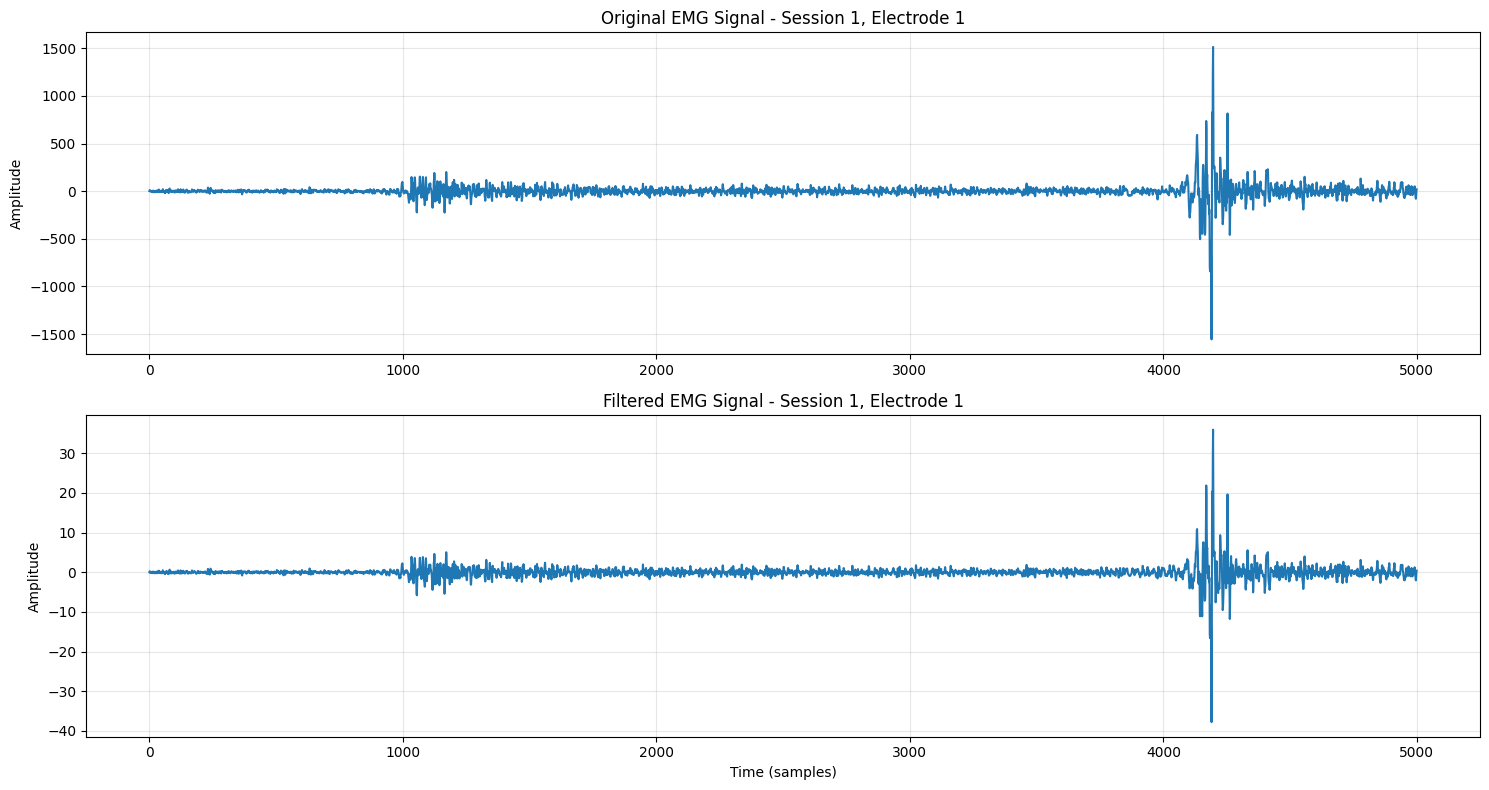

Preprocessing completed in 4.54 seconds

Step 3: Creating windows with overlap...
Window size: 500, Overlap: 50%, Step size: 250
First few window indices to verify 50% overlap:
Window 1: Session 1, Samples 1-500
Window 2: Session 1, Samples 251-750
Window 3: Session 1, Samples 501-1000
Window 4: Session 1, Samples 751-1250
Window 5: Session 1, Samples 1001-1500
Window creation completed in 5.76 seconds
Created 4595 windows with 50% overlap
X_windows shape: (4595, 8, 500)
y_windows shape: (4595, 51, 500)
Target values shape: (4595, 51)

Step 5: Extracting features...
Extracted features shape: (4595, 64)
Number of features: 64
Feature types: ['MAV', 'RMS', 'VAR', 'STD', 'ZC', 'MPR', 'SSC', 'WL']

Performing feature selection and model comparison with proper external cross-validation...

Creating leave-one-session-out cross-validation splits:
Split 1: 3676 training windows, 919 test windows
Split 2: 3676 training windows, 919 test windows
Split 3: 3676 training windows, 919 test windows
S

c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.879e+02, tolerance: 4.374e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\sklearn\linear_model\_

  Selected features: ['E1_MAV', 'E1_RMS', 'E2_MAV', 'E2_RMS', 'E2_VAR', 'E2_WL', 'E3_MAV', 'E3_RMS', 'E3_WL', 'E4_MAV']... (showing first 10)
  Optimal number of features: 19
  Time taken: 457.03 seconds


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(



Performing Feature Importance selection for Lasso on fold 2...


...

  RMSE with top 20 features: 7.7375


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(


  RMSE with top 40 features: 7.7681


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(


  RMSE with top 64 features: 7.7101
  Best number of features: 64 with RMSE: 7.7101
  Time taken: 50.26 seconds

Performing RFECV feature selection for RandomForest on fold 2...
  Selected features: ['E1_MAV', 'E1_WL', 'E2_MAV', 'E2_RMS', 'E2_WL', 'E3_WL', 'E4_MAV', 'E4_WL', 'E5_WL', 'E7_MAV']... (showing first 10)
  Optimal number of features: 16
  Time taken: 1090.17 seconds

Performing Feature Importance selection for RandomForest on fold 2...
  RMSE with top 5 features: 5.1884
  RMSE with top 10 features: 6.0376
  RMSE with top 20 features: 4.9453
  RMSE with top 40 features: 4.7824
  RMSE with top 64 features: 4.8100
  Best number of features: 40 with RMSE: 4.7824
  Time taken: 148.18 seconds

Best configuration for fold 2:
  Model: RandomForest
  Selection Method: Importance
  Number of Features: 40
  Test RMSE: 4.7824
  Test NMSE: 0.1227

Processing fold 3/5

Performing RFECV feature selection for Ridge on fold 3...
  Selected features: ['E1_MAV', 'E1_RMS', 'E1_VAR', 'E1_STD', '

In [ ]:
##FINAL PIPELINE
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Import other modules
# from feature_selection import select_optimal_features
# from metrics import calculate_metrics, visualize_metrics_comparison

# Main pipeline for guided dataset
if __name__ == "__main__":
    # Settings
    window_size = 500
    overlap_percent = 50
    apply_filtering = True  # Define this variable at the top level
    normalize = True        # Define normalization setting
    
    
    print("Processing guided gestures dataset...")
    
    # Check if data is loaded
    if 'guided_X' not in globals() or 'guided_y' not in globals():
        print("Error: guided_X or guided_y not defined")
        print("Please load the datasets first:")
        print("guided_X = np.load('guided_dataset_X.npy')")
        print("guided_y = np.load('guided_dataset_y.npy')")
    else:
        # 1. Check data quality
        print("\nStep 1: Checking EMG data quality...")
        quality_report = check_emg_data_quality(guided_X)
        print(f"NaN values: {quality_report['nan_count']}")
        print(f"Infinite values: {quality_report['inf_count']}")
        
        if 'electrode_stats' in quality_report:
            print("\nElectrode statistics:")
            for stats in quality_report['electrode_stats']:
                print(f"Electrode {stats['electrode']}: Mean={stats['mean']:.2f}, STD={stats['std']:.2f}, SNR={stats['signal_to_noise']:.2f}")
        
        # 2. Apply preprocessing (filtering and normalization)
        print("\nStep 2: Applying signal preprocessing...")
        start_time = time.time()
        
        # Use the enhanced preprocessing function with visualization
        processed_X = preprocess_emg_data(
            guided_X, 
            apply_filtering=apply_filtering,
            normalize=normalize,
            visualize=True,  # Set to True to visualize the filtering effect
            session_id=0,    # First session
            electrode_id=0,  # First electrode
            time_segment=slice(0, 5000)  # First 5000 samples
        )
        
        print(f"Preprocessing completed in {time.time() - start_time:.2f} seconds")
        
        # 3. Create windows with overlap
        print("\nStep 3: Creating windows with overlap...")
        start_time = time.time()
        X_windows, y_windows, window_indices = create_matching_windows(
            processed_X, guided_y, window_size=window_size, overlap_percent=overlap_percent
        )
        print(f"Window creation completed in {time.time() - start_time:.2f} seconds")
        print(f"Created {len(window_indices)} windows with {overlap_percent}% overlap")
        print(f"X_windows shape: {X_windows.shape}")
        print(f"y_windows shape: {y_windows.shape}")

        
        # 4. Calculate mean joint angle in each window as the target
        y_targets = np.mean(y_windows, axis=2)
        print(f"Target values shape: {y_targets.shape}")
        
        # 5. Extract features
        print("\nStep 5: Extracting features...")
        feature_extractor = EMGFeatureExtractor() 
        X_features = feature_extractor.transform(X_windows)
        feature_names = feature_extractor.get_feature_names()
        print(f"Extracted features shape: {X_features.shape}")
        print(f"Number of features: {len(feature_names)}")
        print(f"Feature types: {feature_extractor.all_features}")
        
        # 6. Feature selection and model comparison with proper external cross-validation
        # Replace the old feature selection function with the new one
        best_config, best_features_by_fold, feature_selection_results, all_models_results = select_optimal_features_with_proper_cv(
            X_features, 
            y_targets, 
            window_indices, 
            n_sessions=guided_X.shape[0],
            feature_names=feature_names
        )
        
        # 7. Train final model with best feature selection approach
        print(f"\nStep 7: Training final model with selected features...")
        start_time = time.time()
        
        # Get the consensus features from the best model and method
        best_model_name = best_config['Model']
        best_method = best_config['Selection Method']
        
        # Count feature frequency across folds
        all_selected_features = []
        for fold in range(len(best_features_by_fold) // 2):  # Divide by 2 because we store 2 methods per fold
            key = f"{best_model_name}_fold{fold}"
            if key in best_features_by_fold and best_method in best_features_by_fold[key]:
                selected = best_features_by_fold[key][best_method]
                all_selected_features.extend(selected)
        
        # Count feature frequency
        feature_counts = {}
        for feature in all_selected_features:
            if feature in feature_counts:
                feature_counts[feature] += 1
            else:
                feature_counts[feature] = 1
        
        # Get features selected in at least half of the folds
        min_folds = guided_X.shape[0] // 2
        consensus_features = [feature for feature, count in feature_counts.items() if count >= min_folds]
        
        print(f"Selected {len(consensus_features)} consensus features that appeared in at least {min_folds} folds")
        
        # Create feature extractor with optimal features selected
        optimal_feature_extractor = EMGFeatureExtractor(selected_features=consensus_features)
        
        # Create final model pipeline based on best configuration
        if best_model_name == 'Ridge':
            final_model = Pipeline([
                ('scaler', StandardScaler()),
                ('regressor', Ridge(alpha=1.0))
            ])
        elif best_model_name == 'Lasso':
            final_model = Pipeline([
                ('scaler', StandardScaler()),
                ('regressor', Lasso(alpha=0.01, max_iter=10000))
            ])
        else:
            final_model = Pipeline([
                ('scaler', StandardScaler()),
                ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
            ])
        
        # Extract features with optimal selection
        X_final = optimal_feature_extractor.transform(X_windows)
        
        # Train final model
        final_model.fit(X_final, y_targets)
        print(f"Training completed in {time.time() - start_time:.2f} seconds")
        
        # 8. Generate predictions for test data (if available)
        if 'guided_testset_X' in globals():
            print("\nStep 8: Generating predictions for test data...")
            start_time = time.time()
            
            # Process test data with batch processing for speed
            n_sessions, n_windows, n_electrodes, window_size = guided_testset_X.shape
            batch_size = 50  # Process in batches for speed
            
            # Initialize array for all predictions
            test_predictions = np.zeros((n_sessions * n_windows, y_targets.shape[1]))
            
            # Extract features from all test windows in batches
            current_idx = 0
            
            for session in range(n_sessions):
                print(f"Processing session {session+1}/{n_sessions}...")
                
                # Process all windows for this session
                for batch_start in range(0, n_windows, batch_size):
                    batch_end = min(batch_start + batch_size, n_windows)
                    batch_size_actual = batch_end - batch_start
                    
                    # Prepare batch data
                    batch_windows = guided_testset_X[session, batch_start:batch_end]
                    
                    # Reshape for processing
                    batch_windows_reshaped = batch_windows.reshape(batch_size_actual, n_electrodes, window_size)
                    
                    # Apply filtering and preprocessing
                    if apply_filtering:
                        # Use the new preprocess_emg_data function instead of recommended_emg_filter
                        batch_windows_processed = preprocess_emg_data(
                            batch_windows_reshaped, 
                            apply_filtering=apply_filtering,
                            normalize=normalize,
                            visualize=False  # Don't visualize test data
                        )
                    else:
                        batch_windows_processed = batch_windows_reshaped
                    
                    # Extract features with optimal feature selection
                    batch_features = optimal_feature_extractor.transform(batch_windows_processed)
                    
                    # Generate predictions
                    batch_predictions = final_model.predict(batch_features)
                    
                    # Store predictions
                    for i in range(batch_size_actual):
                        test_predictions[current_idx] = batch_predictions[i]
                        current_idx += 1
                    
                    # Progress update
                    if batch_end % (batch_size * 2) == 0 or batch_end == n_windows:
                        percent_done = (current_idx / (n_sessions * n_windows)) * 100
                        print(f"  Processed {current_idx}/{n_sessions * n_windows} windows ({percent_done:.1f}%)")
            
            print(f"Generated predictions shape: {test_predictions.shape}")
            print(f"Prediction completed in {time.time() - start_time:.2f} seconds")
            
            # Save predictions to CSV
            print("\nSaving predictions to guided_predictions.csv...")
            np.savetxt('guided_predictions.csv', test_predictions, delimiter=',')
            print("Predictions saved successfully!")
        else:
            print("\nTest data not found. If you have the test data, please load it with:")
            print("guided_testset_X = np.load('guided_testset_X.npy')")

Check what is the function of the features selection in the model choice, sleection, training etc etc

## Neural Network 2.0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold

class EMGNet(nn.Module):
    """
    Neural Network for EMG-based hand pose prediction.
    Takes EMG features as input and outputs joint angles.
    """
    def __init__(self, input_size, output_size=51, hidden_sizes=[256, 128, 64]):
        """
        Initialize the neural network.
        
        Parameters:
        -----------
        input_size : int
            Number of input features
        output_size : int
            Number of output values (joint angles)
        hidden_sizes : list
            Sizes of the hidden layers
        """
        super(EMGNet, self).__init__()
        
        # Create a list to hold all layers
        layers = []
        
        # Input layer
        prev_size = input_size
        
        # Hidden layers
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.Dropout(0.2))  # Add dropout for regularization
            prev_size = hidden_size
        
        # Output layer
        layers.append(nn.Linear(prev_size, output_size))
        
        # Combine all layers into a sequential model
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        Forward pass through the network.
        
        Parameters:
        -----------
        x : torch.Tensor
            Input tensor of shape (batch_size, input_size)
            
        Returns:
        --------
        torch.Tensor
            Output tensor of shape (batch_size, output_size)
        """
        return self.model(x)

def train_neural_network(X_train, y_train, X_val=None, y_val=None, input_size=None, output_size=51, 
                         hidden_sizes=[256, 128, 64], batch_size=64, learning_rate=0.001, 
                         num_epochs=100, device="cpu", early_stopping=True, patience=10):
    """
    Train a neural network for EMG-based hand pose prediction.
    
    Parameters:
    -----------
    X_train : numpy.ndarray
        Training features
    y_train : numpy.ndarray
        Training targets
    X_val : numpy.ndarray, optional
        Validation features
    y_val : numpy.ndarray, optional
        Validation targets
    input_size : int, optional
        Number of input features (inferred from X_train if None)
    output_size : int, optional
        Number of output values (default: 51 for joint angles)
    hidden_sizes : list, optional
        Sizes of hidden layers
    batch_size : int, optional
        Batch size for training
    learning_rate : float, optional
        Learning rate for optimizer
    num_epochs : int, optional
        Number of training epochs
    device : str, optional
        Device to train on ('cpu' or 'cuda')
    early_stopping : bool, optional
        Whether to use early stopping
    patience : int, optional
        Number of epochs to wait for improvement before stopping
        
    Returns:
    --------
    model : EMGNet
        Trained neural network model
    history : dict
        Training history containing loss values
    """
    # Determine input size if not provided
    if input_size is None:
        input_size = X_train.shape[1]
    
    # Convert data to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train)
    
    # Create dataset and dataloader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize validation dataloader if validation data is provided
    if X_val is not None and y_val is not None:
        X_val_tensor = torch.FloatTensor(X_val)
        y_val_tensor = torch.FloatTensor(y_val)
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    else:
        val_loader = None
    
    # Initialize model
    model = EMGNet(input_size, output_size, hidden_sizes).to(device)
    
    # Define loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    # Use learning rate scheduler for better convergence
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [] if val_loader else None
    }
    
    # Early stopping variables
    best_val_loss = float('inf')
    best_model_state = None
    no_improvement = 0
    
    # Training loop
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            # Move data to device
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Zero the gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * batch_X.size(0)
        
        # Calculate average training loss
        train_loss = train_loss / len(train_loader.dataset)
        history['train_loss'].append(train_loss)
        
        # Validation phase
        if val_loader:
            model.eval()
            val_loss = 0.0
            
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    # Move data to device
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    
                    # Forward pass
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    
                    val_loss += loss.item() * batch_X.size(0)
            
            # Calculate average validation loss
            val_loss = val_loss / len(val_loader.dataset)
            history['val_loss'].append(val_loss)
            
            # Update learning rate based on validation loss
            scheduler.step(val_loss)
            
            # Print progress
            print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")
            
            # Early stopping check
            if early_stopping:
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_model_state = model.state_dict().copy()
                    no_improvement = 0
                else:
                    no_improvement += 1
                
                if no_improvement >= patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    # Load the best model
                    model.load_state_dict(best_model_state)
                    break
        else:
            # Print progress without validation
            print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}")
    
    # If early stopping was used, make sure we return the best model
    if early_stopping and val_loader and best_model_state:
        model.load_state_dict(best_model_state)
    
    return model, history

def neural_network_cross_validate(X, y, window_indices, n_sessions=5, input_size=None, output_size=51, 
                                 hidden_sizes=[256, 128, 64], batch_size=64, learning_rate=0.001, 
                                 num_epochs=50, device="cpu"):
    """
    Perform leave-one-session-out cross-validation for neural network model.
    
    Parameters:
    -----------
    X : numpy.ndarray
        Feature matrix
    y : numpy.ndarray
        Target values
    window_indices : list of tuples
        List of (session_idx, start_idx, end_idx) for each window
    n_sessions : int, optional
        Number of sessions for cross-validation
    input_size : int, optional
        Number of input features (inferred from X if None)
    output_size : int, optional
        Number of output values (default: 51 for joint angles)
    hidden_sizes : list, optional
        Sizes of hidden layers
    batch_size : int, optional
        Batch size for training
    learning_rate : float, optional
        Learning rate for optimizer
    num_epochs : int, optional
        Number of training epochs
    device : str, optional
        Device to train on ('cpu' or 'cuda')
        
    Returns:
    --------
    results : dict
        Cross-validation results including RMSE, NMSE and trained model
    """
    # Extract session indices for each window
    session_indices = np.array([idx[0] for idx in window_indices])
    
    # Metrics for each fold
    fold_rmse = []
    fold_nmse = []
    best_model = None
    best_rmse = float('inf')
    
    # Loop through each session as validation set
    for test_session in range(n_sessions):
        print(f"\nTraining on all sessions except {test_session+1}...")
        
        # Windows from the test session
        test_idx = np.where(session_indices == test_session)[0]
        # Windows from all other sessions
        train_idx = np.where(session_indices != test_session)[0]
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Train neural network
        model, history = train_neural_network(
            X_train, y_train, X_val=X_test, y_val=y_test,
            input_size=input_size, output_size=output_size,
            hidden_sizes=hidden_sizes, batch_size=batch_size,
            learning_rate=learning_rate, num_epochs=num_epochs,
            device=device
        )
        
        # Make predictions on test set
        model.eval()
        with torch.no_grad():
            X_test_tensor = torch.FloatTensor(X_test).to(device)
            y_pred = model(X_test_tensor).cpu().numpy()
        
        # Calculate metrics
        metrics = calculate_metrics(y_test, y_pred)
        rmse = metrics['rmse']
        nmse = metrics['nmse']
        
        fold_rmse.append(rmse)
        fold_nmse.append(nmse)
        
        print(f"Session {test_session+1} - RMSE: {rmse:.4f}, NMSE: {nmse:.4f}")
        
        # Keep track of the best model
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model
    
    # Calculate average metrics
    avg_rmse = np.mean(fold_rmse)
    avg_nmse = np.mean(fold_nmse)
    
    print(f"\nAverage RMSE across all folds: {avg_rmse:.4f}")
    print(f"Average NMSE across all folds: {avg_nmse:.4f}")
    
    # Return results
    results = {
        'model': best_model,
        'rmse': fold_rmse,
        'avg_rmse': avg_rmse,
        'nmse': fold_nmse,
        'avg_nmse': avg_nmse
    }
    
    return results

def plot_learning_curves(history):
    """
    Plot learning curves from training history.
    
    Parameters:
    -----------
    history : dict
        Training history containing loss values
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_loss'], label='Training Loss')
    
    if history['val_loss']:
        plt.plot(history['val_loss'], label='Validation Loss')
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('neural_network_learning_curves.png', dpi=300)
    plt.show()

def compare_with_baseline_models(nn_results, all_models_results):
    """
    Compare neural network results with baseline models.
    
    Parameters:
    -----------
    nn_results : dict
        Neural network cross-validation results
    all_models_results : dict
        Results from baseline models (Ridge, Lasso, Random Forest)
    """
    # Prepare data for plotting
    models = list(all_models_results.keys()) + ['Neural Network']
    rmse_values = [all_models_results[model]['rmse'] for model in all_models_results.keys()]
    rmse_values.append(nn_results['avg_rmse'])
    nmse_values = [all_models_results[model]['nmse'] for model in all_models_results.keys()]
    nmse_values.append(nn_results['avg_nmse'])
    
    # Plot RMSE comparison
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(models)), rmse_values, width=0.6)
    
    # Add value labels on top of each bar
    for i, (bar, val) in enumerate(zip(bars, rmse_values)):
        plt.text(i, val + 0.01, f"{val:.4f}", ha='center')
    
    # Add labels and title
    plt.xlabel('Model')
    plt.ylabel('RMSE')
    plt.title('Model Performance Comparison (RMSE)')
    plt.xticks(range(len(models)), models, rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('model_comparison_rmse.png', dpi=300)
    plt.show()
    
    # Plot NMSE comparison
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(models)), nmse_values, width=0.6)
    
    # Add value labels on top of each bar
    for i, (bar, val) in enumerate(zip(bars, nmse_values)):
        plt.text(i, val + 0.01, f"{val:.4f}", ha='center')
    
    # Add labels and title
    plt.xlabel('Model')
    plt.ylabel('NMSE')
    plt.title('Model Performance Comparison (NMSE)')
    plt.xticks(range(len(models)), models, rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('model_comparison_nmse.png', dpi=300)
    plt.show()

Processing guided gestures dataset using Neural Network approach...

Step 1: Applying signal filtering...
Applying bandpass and notch filters to EMG signals...
Normalizing EMG channels...
Filtering completed in 1.96 seconds

Step 2: Creating windows with overlap...
Window size: 500, Overlap: 50%, Step size: 250
First few window indices to verify 50% overlap:
Window 1: Session 1, Samples 1-500
Window 2: Session 1, Samples 251-750
Window 3: Session 1, Samples 501-1000
Window 4: Session 1, Samples 751-1250
Window 5: Session 1, Samples 1001-1500
Window creation completed in 5.90 seconds
Created 4595 windows with 50% overlap
X_windows shape: (4595, 8, 500)
y_windows shape: (4595, 51, 500)
Target values shape: (4595, 51)

Step 4: Extracting features...
Extracted features shape: (4595, 64)
Number of features: 64

Step 5: Standardizing features...
Using device: cpu

Step 7: Performing neural network cross-validation...

Training on all sessions except 1...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50 - Train Loss: 460.8645 - Val Loss: 441.5660
Epoch 2/50 - Train Loss: 406.5626 - Val Loss: 384.2472
Epoch 3/50 - Train Loss: 354.0470 - Val Loss: 334.1048
Epoch 4/50 - Train Loss: 310.6348 - Val Loss: 288.7593
Epoch 5/50 - Train Loss: 269.6227 - Val Loss: 228.7147
Epoch 6/50 - Train Loss: 228.4794 - Val Loss: 195.8672
Epoch 7/50 - Train Loss: 187.4201 - Val Loss: 171.2564
Epoch 8/50 - Train Loss: 147.6957 - Val Loss: 128.8179
Epoch 9/50 - Train Loss: 118.0595 - Val Loss: 104.6507
Epoch 10/50 - Train Loss: 94.8643 - Val Loss: 77.6862
Epoch 11/50 - Train Loss: 76.5890 - Val Loss: 67.7745
Epoch 12/50 - Train Loss: 63.9103 - Val Loss: 54.6966
Epoch 13/50 - Train Loss: 55.6880 - Val Loss: 47.3033
Epoch 14/50 - Train Loss: 47.5797 - Val Loss: 39.9525
Epoch 15/50 - Train Loss: 43.1798 - Val Loss: 34.1114
Epoch 16/50 - Train Loss: 39.0383 - Val Loss: 30.1461
Epoch 17/50 - Train Loss: 34.6590 - Val Loss: 27.7777
Epoch 18/50 - Train Loss: 32.3593 - Val Loss: 25.3661
Epoch 19/50 - Train

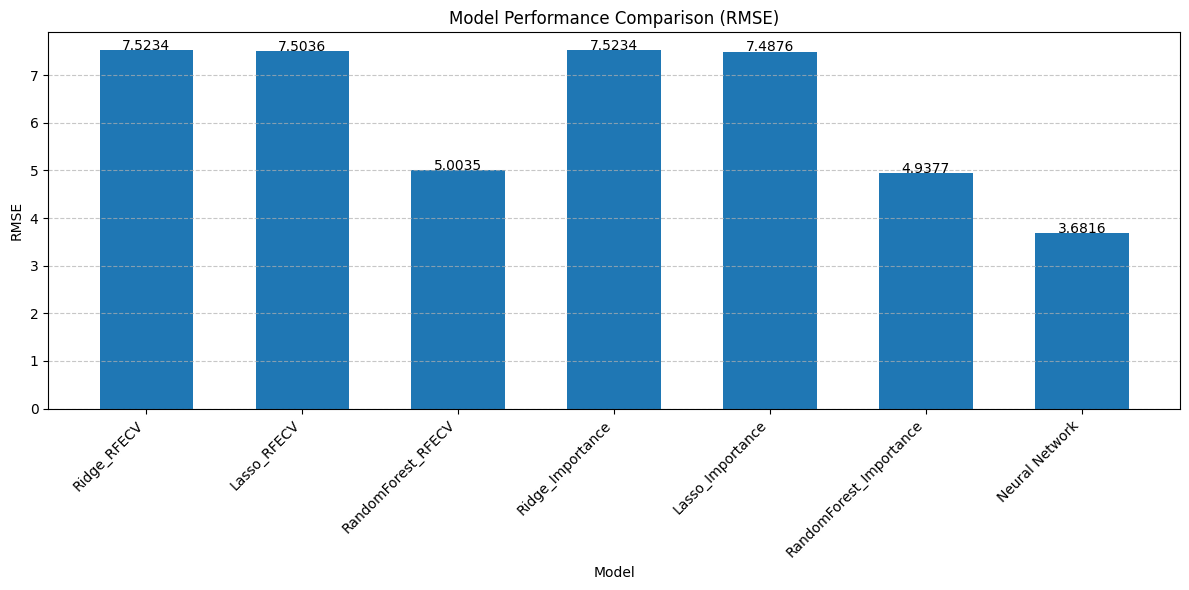

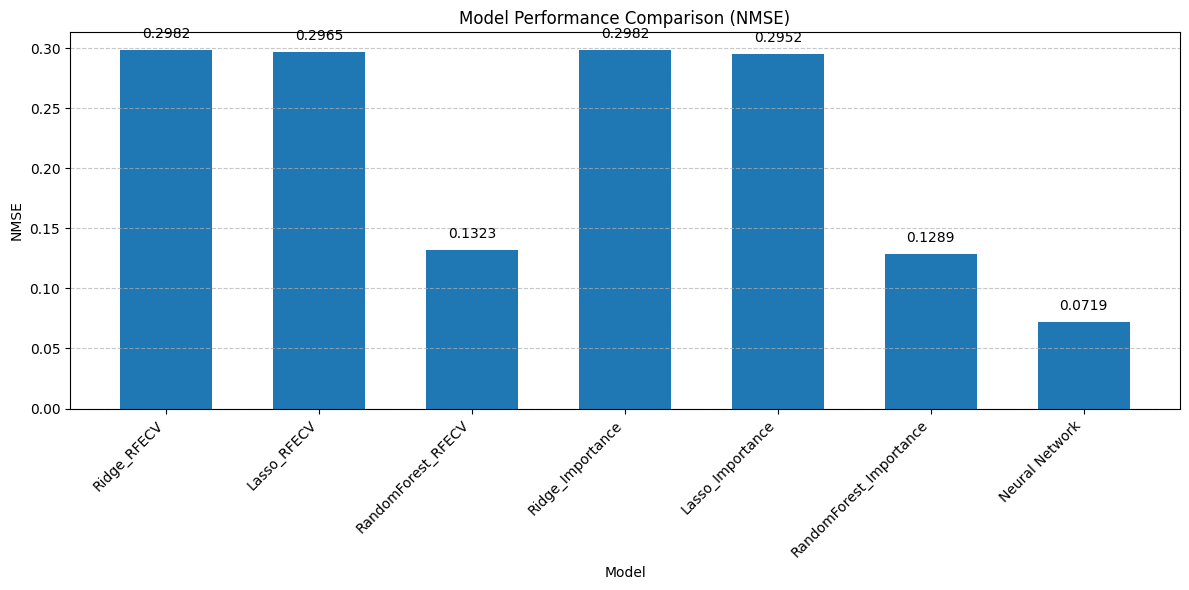


Model Performance Summary:
-------------------------
Ridge_RFECV: RMSE = 7.5234, NMSE = 0.2982
Lasso_RFECV: RMSE = 7.5036, NMSE = 0.2965
RandomForest_RFECV: RMSE = 5.0035, NMSE = 0.1323
Ridge_Importance: RMSE = 7.5234, NMSE = 0.2982
Lasso_Importance: RMSE = 7.4876, NMSE = 0.2952
RandomForest_Importance: RMSE = 4.9377, NMSE = 0.1289
Neural Network: RMSE = 3.6816, NMSE = 0.0719

Step 9: Training final neural network model on all data...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50 - Train Loss: 456.8330
Epoch 2/50 - Train Loss: 390.5122
Epoch 3/50 - Train Loss: 329.5531
Epoch 4/50 - Train Loss: 276.1764
Epoch 5/50 - Train Loss: 224.3601
Epoch 6/50 - Train Loss: 171.7722
Epoch 7/50 - Train Loss: 128.6768
Epoch 8/50 - Train Loss: 96.3694
Epoch 9/50 - Train Loss: 73.5415
Epoch 10/50 - Train Loss: 60.1888
Epoch 11/50 - Train Loss: 47.4484
Epoch 12/50 - Train Loss: 41.6237
Epoch 13/50 - Train Loss: 36.7138
Epoch 14/50 - Train Loss: 32.7352
Epoch 15/50 - Train Loss: 29.1645
Epoch 16/50 - Train Loss: 29.4052
Epoch 17/50 - Train Loss: 26.4647
Epoch 18/50 - Train Loss: 24.3247
Epoch 19/50 - Train Loss: 23.8397
Epoch 20/50 - Train Loss: 21.7324
Epoch 21/50 - Train Loss: 22.0731
Epoch 22/50 - Train Loss: 22.5899
Epoch 23/50 - Train Loss: 23.7347
Epoch 24/50 - Train Loss: 21.2330
Epoch 25/50 - Train Loss: 21.2146
Epoch 26/50 - Train Loss: 22.7588
Epoch 27/50 - Train Loss: 21.5264
Epoch 28/50 - Train Loss: 19.4098
Epoch 29/50 - Train Loss: 19.6006
Epoch 30/50 - Tr

In [ ]:
##NEURAL NETWORK PIPELINE
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# Main pipeline for neural network approach
if __name__ == "__main__":
    # Settings
    window_size = 500
    overlap_percent = 50
    apply_filtering = True  # Apply signal filtering
    normalize = True  # Define normalization setting
    
    print("Processing guided gestures dataset using Neural Network approach...")
    
    # Check if data is loaded
    if 'guided_X' not in globals() or 'guided_y' not in globals():
        print("Error: guided_X or guided_y not defined")
        print("Please load the datasets first:")
        print("guided_X = np.load('guided_dataset_X.npy')")
        print("guided_y = np.load('guided_dataset_y.npy')")
    else:
        # 1. If filtering is enabled, apply it to the raw EMG data
        if apply_filtering:
            print("\nStep 1: Applying signal filtering...")
            start_time = time.time()
            
            # Use preprocess_emg_data instead of recommended_emg_filter
            filtered_X = preprocess_emg_data(
                guided_X, 
                apply_filtering=True,
                normalize=normalize,
                visualize=False
            )
            print(f"Filtering completed in {time.time() - start_time:.2f} seconds")
            
            # Use the filtered data for further processing
            data_to_use = filtered_X
        else:
            # Use raw data if filtering is disabled
            data_to_use = guided_X
        
        # 2. Create windows with overlap
        print("\nStep 2: Creating windows with overlap...")
        start_time = time.time()
        X_windows, y_windows, window_indices = create_matching_windows(
            data_to_use, guided_y, window_size=window_size, overlap_percent=overlap_percent
        )
        print(f"Window creation completed in {time.time() - start_time:.2f} seconds")
        print(f"Created {len(window_indices)} windows with {overlap_percent}% overlap")
        print(f"X_windows shape: {X_windows.shape}")
        print(f"y_windows shape: {y_windows.shape}")
        
        # 3. Calculate mean joint angle in each window as the target
        y_targets = np.mean(y_windows, axis=2)
        print(f"Target values shape: {y_targets.shape}")
        
        # 4. Extract features
        print("\nStep 4: Extracting features...")
        feature_extractor = EMGFeatureExtractor()  # Using all features
        X_features = feature_extractor.transform(X_windows)
        feature_names = feature_extractor.get_feature_names()
        print(f"Extracted features shape: {X_features.shape}")
        print(f"Number of features: {len(feature_names)}")
        
        # 5. Standardize features for neural network
        print("\nStep 5: Standardizing features...")
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_features)
        
        # 6. Neural Network hyperparameters
        input_size = X_scaled.shape[1]  # Number of features
        output_size = y_targets.shape[1]  # Number of joint angles (51)
        hidden_sizes = [256, 128, 64]  # Hidden layer sizes
        batch_size = 64
        learning_rate = 0.001
        num_epochs = 50
        
        # Check if GPU is available
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {device}")
        
        # 7. Perform cross-validation with neural network
        print("\nStep 7: Performing neural network cross-validation...")
        start_time = time.time()
        nn_results = neural_network_cross_validate(
            X_scaled, y_targets, window_indices,
            n_sessions=guided_X.shape[0],
            input_size=input_size,
            output_size=output_size,
            hidden_sizes=hidden_sizes,
            batch_size=batch_size,
            learning_rate=learning_rate,
            num_epochs=num_epochs,
            device=device
        )
        print(f"Neural network cross-validation completed in {time.time() - start_time:.2f} seconds")
        
        # 8. Compare with baseline models if available
        if 'all_models_results' in globals():
            print("\nStep 8: Comparing neural network with baseline models...")
            nn_metrics = {
                'Neural Network': {
                    'rmse': nn_results['avg_rmse'],
                    'nmse': nn_results['avg_nmse']
                }
            }
            
            # Create a comprehensive dictionary with all models
            all_metrics = {}
            for model_name, metrics in all_models_results.items():
                all_metrics[model_name] = metrics
            all_metrics.update(nn_metrics)
            
            # Plot comparison
            models = list(all_metrics.keys())
            rmse_values = [all_metrics[model]['rmse'] for model in models]
            nmse_values = [all_metrics[model]['nmse'] for model in models]
            
            # RMSE comparison
            plt.figure(figsize=(12, 6))
            bars = plt.bar(range(len(models)), rmse_values, width=0.6)
            
            # Add value labels
            for i, (bar, val) in enumerate(zip(bars, rmse_values)):
                plt.text(i, val + 0.01, f"{val:.4f}", ha='center')
            
            plt.xlabel('Model')
            plt.ylabel('RMSE')
            plt.title('Model Performance Comparison (RMSE)')
            plt.xticks(range(len(models)), models, rotation=45, ha='right')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.savefig('model_comparison_rmse.png', dpi=300)
            plt.show()
            
            # NMSE comparison
            plt.figure(figsize=(12, 6))
            bars = plt.bar(range(len(models)), nmse_values, width=0.6)
            
            # Add value labels
            for i, (bar, val) in enumerate(zip(bars, nmse_values)):
                plt.text(i, val + 0.01, f"{val:.4f}", ha='center')
            
            plt.xlabel('Model')
            plt.ylabel('NMSE')
            plt.title('Model Performance Comparison (NMSE)')
            plt.xticks(range(len(models)), models, rotation=45, ha='right')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.savefig('model_comparison_nmse.png', dpi=300)
            plt.show()
            
            print("\nModel Performance Summary:")
            print("-------------------------")
            for model in models:
                print(f"{model}: RMSE = {all_metrics[model]['rmse']:.4f}, NMSE = {all_metrics[model]['nmse']:.4f}")
        
        # 9. Train final neural network model on all data if needed for test data prediction
        if 'guided_testset_X' in globals():
            print("\nStep 9: Training final neural network model on all data...")
            start_time = time.time()
            
            # Train on all available data
            final_nn_model, _ = train_neural_network(
                X_scaled, y_targets,
                input_size=input_size,
                output_size=output_size,
                hidden_sizes=hidden_sizes,
                batch_size=batch_size,
                learning_rate=learning_rate,
                num_epochs=num_epochs,
                device=device,
                early_stopping=False  # Use all epochs when training final model
            )
            
            print(f"Final model training completed in {time.time() - start_time:.2f} seconds")
            
            # 10. Generate predictions for test data
            print("\nStep 10: Generating predictions for test data...")
            start_time = time.time()
            
            # Process test data with batch processing for speed
            n_sessions, n_windows, n_electrodes, window_size = guided_testset_X.shape
            batch_size = 50  # Process in batches for speed
            
            # Initialize array for all predictions
            test_predictions = np.zeros((n_sessions * n_windows, y_targets.shape[1]))
            
            # Extract features from all test windows in batches
            current_idx = 0
            
            for session in range(n_sessions):
                print(f"Processing session {session+1}/{n_sessions}...")
                
                # Process all windows for this session
                for batch_start in range(0, n_windows, batch_size):
                    batch_end = min(batch_start + batch_size, n_windows)
                    batch_size_actual = batch_end - batch_start
                    
                    # Prepare batch data
                    batch_windows = guided_testset_X[session, batch_start:batch_end]
                    
                    # Reshape for processing
                    batch_windows_reshaped = batch_windows.reshape(batch_size_actual, n_electrodes, window_size)
                    
                    # Apply filtering if needed
                    if apply_filtering:
                        # Use preprocess_emg_data instead of the old approach
                        batch_windows_processed = preprocess_emg_data(
                            batch_windows_reshaped, 
                            apply_filtering=True,
                            normalize=normalize,
                            visualize=False
                        )
                        batch_windows_reshaped = batch_windows_processed
                    
                    # Extract features
                    batch_features = feature_extractor.transform(batch_windows_reshaped)
                    
                    # Standardize features using the same scaler
                    batch_features_scaled = scaler.transform(batch_features)
                    
                    # Convert to PyTorch tensor
                    batch_tensor = torch.FloatTensor(batch_features_scaled).to(device)
                    
                    # Generate predictions with neural network
                    final_nn_model.eval()
                    with torch.no_grad():
                        batch_predictions = final_nn_model(batch_tensor).cpu().numpy()
                    
                    # Store predictions
                    for i in range(batch_size_actual):
                        test_predictions[current_idx] = batch_predictions[i]
                        current_idx += 1
                    
                    # Progress update
                    if batch_end % (batch_size * 2) == 0 or batch_end == n_windows:
                        percent_done = (current_idx / (n_sessions * n_windows)) * 100
                        print(f"  Processed {current_idx}/{n_sessions * n_windows} windows ({percent_done:.1f}%)")
            
            print(f"Generated predictions shape: {test_predictions.shape}")
            print(f"Prediction completed in {time.time() - start_time:.2f} seconds")
            
            # Save predictions to CSV
            print("\nSaving neural network predictions to nn_guided_predictions.csv...")
            np.savetxt('nn_guided_predictions.csv', test_predictions, delimiter=',')
            print("Predictions saved successfully!")
        else:
            print("\nTest data not found. If you have the test data, please load it with:")
            print("guided_testset_X = np.load('guided_testset_X.npy')")

## Ensemble Models

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

def ensemble_averaging(predictions_list, weights=None):
    """
    Implement model averaging ensemble strategy.
    
    Parameters:
    -----------
    predictions_list : list of numpy.ndarray
        List of predictions from different models, each with shape (n_samples, n_targets)
    weights : numpy.ndarray, optional
        Weights for each model. If None, equal weights are used.
        
    Returns:
    --------
    ensemble_predictions : numpy.ndarray
        Averaged predictions with shape (n_samples, n_targets)
    """
    # Convert list to numpy array for easier manipulation
    predictions_array = np.array(predictions_list)
    
    # If weights are provided, ensure they sum to 1
    if weights is not None:
        weights = np.array(weights)
        weights = weights / np.sum(weights)
        # Apply weights along the first axis (models)
        ensemble_predictions = np.sum(predictions_array * weights[:, np.newaxis, np.newaxis], axis=0)
    else:
        # Simple averaging with equal weights
        ensemble_predictions = np.mean(predictions_array, axis=0)
    
    return ensemble_predictions

def train_stacking_ensemble(base_predictions_list, y_true, meta_model=None):
    """
    Train a stacking ensemble (meta-learner) model.
    
    Parameters:
    -----------
    base_predictions_list : list of numpy.ndarray
        List of predictions from base models, each with shape (n_samples, n_targets)
    y_true : numpy.ndarray
        True target values with shape (n_samples, n_targets)
    meta_model : object, optional
        Scikit-learn compatible model to use as meta-learner.
        If None, Ridge regression is used.
        
    Returns:
    --------
    meta_model : object
        Trained meta-learner model
    feature_importances : dict or None
        Feature importances if available in the meta-model
    """
    # Concatenate all base predictions as features for the meta-learner
    n_samples = base_predictions_list[0].shape[0]
    n_targets = y_true.shape[1]
    n_models = len(base_predictions_list)
    
    # Create input matrix for meta-learner
    X_meta = np.zeros((n_samples, n_models * n_targets))
    
    # Fill the meta-learner input with base model predictions
    for i, pred in enumerate(base_predictions_list):
        X_meta[:, i*n_targets:(i+1)*n_targets] = pred
    
    # Default to Ridge regression if no meta-model is provided
    if meta_model is None:
        meta_model = Ridge(alpha=1.0)
    
    # Train meta-learner
    meta_model.fit(X_meta, y_true)
    
    # Extract feature importances if available
    feature_importances = None
    if hasattr(meta_model, 'coef_'):
        # For linear models like Ridge
        importances = np.abs(meta_model.coef_)
        # Average importance across target dimensions
        avg_importances = np.mean(importances, axis=0)
        # Calculate total importance for each base model
        model_importances = [np.sum(avg_importances[i*n_targets:(i+1)*n_targets]) for i in range(n_models)]
        # Normalize to sum to 1
        model_importances = model_importances / np.sum(model_importances)
        feature_importances = model_importances
    
    return meta_model, feature_importances

def predict_with_stacking_ensemble(base_predictions_list, meta_model):
    """
    Generate predictions using a trained stacking ensemble.
    
    Parameters:
    -----------
    base_predictions_list : list of numpy.ndarray
        List of predictions from base models, each with shape (n_samples, n_targets)
    meta_model : object
        Trained meta-learner model
        
    Returns:
    --------
    ensemble_predictions : numpy.ndarray
        Predictions from the stacking ensemble with shape (n_samples, n_targets)
    """
    # Concatenate all base predictions as features for the meta-learner
    n_samples = base_predictions_list[0].shape[0]
    n_targets = base_predictions_list[0].shape[1]
    n_models = len(base_predictions_list)
    
    # Create input matrix for meta-learner
    X_meta = np.zeros((n_samples, n_models * n_targets))
    
    # Fill the meta-learner input with base model predictions
    for i, pred in enumerate(base_predictions_list):
        X_meta[:, i*n_targets:(i+1)*n_targets] = pred
    
    # Generate predictions using meta-learner
    ensemble_predictions = meta_model.predict(X_meta)
    
    return ensemble_predictions

def compare_ensemble_strategies(X_windows, y_targets, window_indices, n_sessions=5, 
                                base_models=None, model_names=None, neural_net=None):
    """
    Compare different ensemble strategies along with base models.
    
    Parameters:
    -----------
    X_windows : numpy.ndarray
        Windowed EMG data
    y_targets : numpy.ndarray
        Target joint angles
    window_indices : list
        List containing session indices for each window
    n_sessions : int
        Number of sessions for cross-validation
    base_models : list
        List of base models to use in ensembles
    model_names : list
        Names of the base models
    neural_net : object
        Neural network model object
        
    Returns:
    --------
    results : dict
        Dictionary containing performance metrics for all models and ensembles
    """
    print("Comparing ensemble strategies...")
    
    # If model_names not provided, create generic names
    if model_names is None:
        model_names = [f"Model_{i+1}" for i in range(len(base_models))]
    
    # Extract session indices for each window
    session_indices = np.array([idx[0] for idx in window_indices])
    
    # Initialize results dictionary
    results = {
        'models': {},
        'ensemble_avg': {'rmse': [], 'nmse': []},
        'ensemble_stack': {'rmse': [], 'nmse': []}
    }
    
    # Performance metrics for each fold
    all_fold_predictions = {}
    for model_name in model_names:
        all_fold_predictions[model_name] = []
        results['models'][model_name] = {'rmse': [], 'nmse': []}
    
    if neural_net:
        all_fold_predictions['Neural Network'] = []
        results['models']['Neural Network'] = {'rmse': [], 'nmse': []}
    
    # Set up feature extractor
    feature_extractor = EMGFeatureExtractor()
    
    # Loop through each session for leave-one-session-out cross-validation
    for test_session in range(n_sessions):
        print(f"\nCross-validation fold {test_session+1}/{n_sessions}")
        
        # Split data into training and testing sets
        test_idx = np.where(session_indices == test_session)[0]
        train_idx = np.where(session_indices != test_session)[0]
        
        X_train, X_test = X_windows[train_idx], X_windows[test_idx]
        y_train, y_test = y_targets[train_idx], y_targets[test_idx]
        
        # Extract features
        X_train_features = feature_extractor.transform(X_train)
        X_test_features = feature_extractor.transform(X_test)
        
        # List to store predictions from all models
        fold_predictions = []
        fold_model_names = []
        
        # Train and evaluate base models
        for i, model in enumerate(base_models):
            model_name = model_names[i]
            print(f"Training {model_name}...")
            
            # Train the model
            model.fit(X_train_features, y_train)
            
            # Generate predictions
            y_pred = model.predict(X_test_features)
            
            # Store predictions for ensemble
            fold_predictions.append(y_pred)
            fold_model_names.append(model_name)
            
            # Calculate metrics
            metrics = calculate_metrics(y_test, y_pred)
            results['models'][model_name]['rmse'].append(metrics['rmse'])
            results['models'][model_name]['nmse'].append(metrics['nmse'])
            
            # Store predictions for this fold
            all_fold_predictions[model_name].append(y_pred)
            
            print(f"{model_name} - RMSE: {metrics['rmse']:.4f}, NMSE: {metrics['nmse']:.4f}")
        
        # If neural network is provided, include its predictions
        if neural_net:
            print("Training Neural Network...")
            
            # Prepare data for neural network
            from sklearn.preprocessing import StandardScaler
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_features)
            X_test_scaled = scaler.transform(X_test_features)
            
            # Convert to PyTorch tensors
            import torch
            X_train_tensor = torch.FloatTensor(X_train_scaled)
            y_train_tensor = torch.FloatTensor(y_train)
            X_test_tensor = torch.FloatTensor(X_test_scaled)
            
            # Create dataset and dataloader
            from torch.utils.data import DataLoader, TensorDataset
            train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
            train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
            
            # Train neural network
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            model, _ = train_neural_network(
                X_train_scaled, y_train,
                input_size=X_train_scaled.shape[1],
                output_size=y_train.shape[1],
                device=device
            )
            
            # Generate predictions
            model.eval()
            with torch.no_grad():
                y_pred_nn = model(X_test_tensor.to(device)).cpu().numpy()
            
            # Store predictions for ensemble
            fold_predictions.append(y_pred_nn)
            fold_model_names.append('Neural Network')
            
            # Calculate metrics
            metrics = calculate_metrics(y_test, y_pred_nn)
            results['models']['Neural Network']['rmse'].append(metrics['rmse'])
            results['models']['Neural Network']['nmse'].append(metrics['nmse'])
            
            # Store predictions for this fold
            all_fold_predictions['Neural Network'].append(y_pred_nn)
            
            print(f"Neural Network - RMSE: {metrics['rmse']:.4f}, NMSE: {metrics['nmse']:.4f}")
        
        # Ensemble Strategy 1: Simple Averaging
        print("\nEnsemble Strategy 1: Simple Averaging")
        avg_predictions = ensemble_averaging(fold_predictions)
        avg_metrics = calculate_metrics(y_test, avg_predictions)
        results['ensemble_avg']['rmse'].append(avg_metrics['rmse'])
        results['ensemble_avg']['nmse'].append(avg_metrics['nmse'])
        print(f"Average Ensemble - RMSE: {avg_metrics['rmse']:.4f}, NMSE: {avg_metrics['nmse']:.4f}")
        
        # Ensemble Strategy 2: Stacking (Meta-Learner)
        print("\nEnsemble Strategy 2: Stacking (Meta-Learner)")
        # Use Ridge regression as meta-learner
        meta_model, model_weights = train_stacking_ensemble(fold_predictions, y_test)
        stack_predictions = predict_with_stacking_ensemble(fold_predictions, meta_model)
        stack_metrics = calculate_metrics(y_test, stack_predictions)
        results['ensemble_stack']['rmse'].append(stack_metrics['rmse'])
        results['ensemble_stack']['nmse'].append(stack_metrics['nmse'])
        
        # Print meta-learner weights if available
        if model_weights is not None:
            print("Meta-learner model weights:")
            for i, model_name in enumerate(fold_model_names):
                print(f"  {model_name}: {model_weights[i]:.4f}")
        
        print(f"Stacking Ensemble - RMSE: {stack_metrics['rmse']:.4f}, NMSE: {stack_metrics['nmse']:.4f}")
    
    # Calculate average metrics across all folds
    for model_name in results['models']:
        results['models'][model_name]['avg_rmse'] = np.mean(results['models'][model_name]['rmse'])
        results['models'][model_name]['avg_nmse'] = np.mean(results['models'][model_name]['nmse'])
    
    results['ensemble_avg']['avg_rmse'] = np.mean(results['ensemble_avg']['rmse'])
    results['ensemble_avg']['avg_nmse'] = np.mean(results['ensemble_avg']['nmse'])
    
    results['ensemble_stack']['avg_rmse'] = np.mean(results['ensemble_stack']['rmse'])
    results['ensemble_stack']['avg_nmse'] = np.mean(results['ensemble_stack']['nmse'])
    
    # Print overall results
    print("\nFinal Results (Averaged across all folds):")
    print("------------------------------------------")
    for model_name in results['models']:
        print(f"{model_name} - RMSE: {results['models'][model_name]['avg_rmse']:.4f}, NMSE: {results['models'][model_name]['avg_nmse']:.4f}")
    
    print(f"Average Ensemble - RMSE: {results['ensemble_avg']['avg_rmse']:.4f}, NMSE: {results['ensemble_avg']['avg_nmse']:.4f}")
    print(f"Stacking Ensemble - RMSE: {results['ensemble_stack']['avg_rmse']:.4f}, NMSE: {results['ensemble_stack']['avg_nmse']:.4f}")
    
    # Plot results comparison
    plot_ensemble_comparison(results)
    
    return results

def plot_ensemble_comparison(results):
    """
    Plot comparison of ensemble methods against base models.
    
    Parameters:
    -----------
    results : dict
        Results dictionary from compare_ensemble_strategies
    """
    # Extract model names and metrics
    model_names = list(results['models'].keys())
    rmse_values = [results['models'][model]['avg_rmse'] for model in model_names]
    nmse_values = [results['models'][model]['avg_nmse'] for model in model_names]
    
    # Add ensemble results
    all_names = model_names + ['Average Ensemble', 'Stacking Ensemble']
    all_rmse = rmse_values + [results['ensemble_avg']['avg_rmse'], results['ensemble_stack']['avg_rmse']]
    all_nmse = nmse_values + [results['ensemble_avg']['avg_nmse'], results['ensemble_stack']['avg_nmse']]
    
    # Plot RMSE comparison
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(all_names)), all_rmse, width=0.6)
    
    # Highlight ensemble bars
    bars[-2].set_color('green')
    bars[-1].set_color('purple')
    
    # Add value labels
    for i, bar in enumerate(bars):
        plt.text(i, bar.get_height() + 0.05, f"{all_rmse[i]:.4f}", ha='center')
    
    plt.xlabel('Model')
    plt.ylabel('RMSE')
    plt.title('Model Performance Comparison - RMSE')
    plt.xticks(range(len(all_names)), all_names, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('ensemble_comparison_rmse.png', dpi=300)
    plt.show()
    
    # Plot NMSE comparison
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(all_names)), all_nmse, width=0.6)
    
    # Highlight ensemble bars
    bars[-2].set_color('green')
    bars[-1].set_color('purple')
    
    # Add value labels
    for i, bar in enumerate(bars):
        plt.text(i, bar.get_height() + 0.05, f"{all_nmse[i]:.4f}", ha='center')
    
    plt.xlabel('Model')
    plt.ylabel('NMSE')
    plt.title('Model Performance Comparison - NMSE')
    plt.xticks(range(len(all_names)), all_names, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('ensemble_comparison_nmse.png', dpi=300)
    plt.show()

Processing guided gestures dataset using Ensemble Strategies...

Step 1: Applying signal filtering...
Applying bandpass and notch filters to EMG signals...
Normalizing EMG channels...
Filtering completed in 1.87 seconds

Step 2: Creating windows with overlap...
Window size: 500, Overlap: 50%, Step size: 250
First few window indices to verify 50% overlap:
Window 1: Session 1, Samples 1-500
Window 2: Session 1, Samples 251-750
Window 3: Session 1, Samples 501-1000
Window 4: Session 1, Samples 751-1250
Window 5: Session 1, Samples 1001-1500
Window creation completed in 16.13 seconds
Created 4595 windows with 50% overlap
X_windows shape: (4595, 8, 500)
y_windows shape: (4595, 51, 500)
Target values shape: (4595, 51)

Step 4: Extracting features...
Extracted features shape: (4595, 64)
Number of features: 64

Step 5: Setting up base models...
PyTorch is available. Including Neural Network in the ensemble.

Step 7: Comparing ensemble strategies...
Comparing ensemble strategies...

Cross-valid

c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100 - Train Loss: 461.2688
Epoch 2/100 - Train Loss: 408.2519
Epoch 3/100 - Train Loss: 355.5439
Epoch 4/100 - Train Loss: 310.1421
Epoch 5/100 - Train Loss: 269.4188
Epoch 6/100 - Train Loss: 228.7587
Epoch 7/100 - Train Loss: 185.4614
Epoch 8/100 - Train Loss: 145.9087
Epoch 9/100 - Train Loss: 113.1465
Epoch 10/100 - Train Loss: 90.2012
Epoch 11/100 - Train Loss: 72.8788
Epoch 12/100 - Train Loss: 60.1187
Epoch 13/100 - Train Loss: 53.1080
Epoch 14/100 - Train Loss: 44.8573
Epoch 15/100 - Train Loss: 39.5034
Epoch 16/100 - Train Loss: 35.2507
Epoch 17/100 - Train Loss: 32.9946
Epoch 18/100 - Train Loss: 30.3488
Epoch 19/100 - Train Loss: 28.4084
Epoch 20/100 - Train Loss: 26.2624
Epoch 21/100 - Train Loss: 26.0377
Epoch 22/100 - Train Loss: 24.7872
Epoch 23/100 - Train Loss: 22.8586
Epoch 24/100 - Train Loss: 22.5888
Epoch 25/100 - Train Loss: 23.9472
Epoch 26/100 - Train Loss: 21.5351
Epoch 27/100 - Train Loss: 22.4769
Epoch 28/100 - Train Loss: 21.0947
Epoch 29/100 - Train

c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.879e+02, tolerance: 4.374e+02
  model = cd_fast.enet_coordinate_descent(


Lasso - RMSE: 7.7100, NMSE: 0.3190
Training Random Forest...
Random Forest - RMSE: 4.7281, NMSE: 0.1200
Training Neural Network...


...

Epoch 1/100 - Train Loss: 463.3493
Epoch 2/100 - Train Loss: 410.3292
Epoch 3/100 - Train Loss: 358.3164
Epoch 4/100 - Train Loss: 313.4337
Epoch 5/100 - Train Loss: 271.2402
Epoch 6/100 - Train Loss: 228.5432
Epoch 7/100 - Train Loss: 187.7117
Epoch 8/100 - Train Loss: 148.4805
Epoch 9/100 - Train Loss: 116.7044
Epoch 10/100 - Train Loss: 90.8570
Epoch 11/100 - Train Loss: 74.8896
Epoch 12/100 - Train Loss: 61.7116
Epoch 13/100 - Train Loss: 52.4300
Epoch 14/100 - Train Loss: 45.6791
Epoch 15/100 - Train Loss: 40.0944
Epoch 16/100 - Train Loss: 35.9609
Epoch 17/100 - Train Loss: 32.8153
Epoch 18/100 - Train Loss: 31.3076
Epoch 19/100 - Train Loss: 30.5834
Epoch 20/100 - Train Loss: 27.6120
Epoch 21/100 - Train Loss: 28.4612
Epoch 22/100 - Train Loss: 24.0826
Epoch 23/100 - Train Loss: 26.0116
Epoch 24/100 - Train Loss: 23.7214
Epoch 25/100 - Train Loss: 24.5678
Epoch 26/100 - Train Loss: 22.0928
Epoch 27/100 - Train Loss: 21.4117
Epoch 28/100 - Train Loss: 23.6560
Epoch 29/100 - Train

c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100 - Train Loss: 464.9360
Epoch 2/100 - Train Loss: 411.2704
Epoch 3/100 - Train Loss: 360.1715
Epoch 4/100 - Train Loss: 313.8799
Epoch 5/100 - Train Loss: 275.6823
Epoch 6/100 - Train Loss: 234.7385
Epoch 7/100 - Train Loss: 192.0231
Epoch 8/100 - Train Loss: 152.1040
Epoch 9/100 - Train Loss: 118.6204
Epoch 10/100 - Train Loss: 94.9990
Epoch 11/100 - Train Loss: 77.4792
Epoch 12/100 - Train Loss: 64.3212
Epoch 13/100 - Train Loss: 56.7254
Epoch 14/100 - Train Loss: 48.3513
Epoch 15/100 - Train Loss: 43.6995
Epoch 16/100 - Train Loss: 39.3889
Epoch 17/100 - Train Loss: 34.4165
Epoch 18/100 - Train Loss: 31.5935
Epoch 19/100 - Train Loss: 28.8916
Epoch 20/100 - Train Loss: 28.6382
Epoch 21/100 - Train Loss: 26.2493
Epoch 22/100 - Train Loss: 26.3247
Epoch 23/100 - Train Loss: 24.5970
Epoch 24/100 - Train Loss: 23.9158
Epoch 25/100 - Train Loss: 22.3340
Epoch 26/100 - Train Loss: 22.6513
Epoch 27/100 - Train Loss: 22.2768
Epoch 28/100 - Train Loss: 21.9223
Epoch 29/100 - Train

c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100 - Train Loss: 460.1522
Epoch 2/100 - Train Loss: 407.7017
Epoch 3/100 - Train Loss: 356.2988
Epoch 4/100 - Train Loss: 310.9935
Epoch 5/100 - Train Loss: 271.7000
Epoch 6/100 - Train Loss: 230.3758
Epoch 7/100 - Train Loss: 187.1453
Epoch 8/100 - Train Loss: 147.8480
Epoch 9/100 - Train Loss: 116.6569
Epoch 10/100 - Train Loss: 90.9690
Epoch 11/100 - Train Loss: 74.6439
Epoch 12/100 - Train Loss: 61.0888
Epoch 13/100 - Train Loss: 53.4482
Epoch 14/100 - Train Loss: 45.1560
Epoch 15/100 - Train Loss: 40.3613
Epoch 16/100 - Train Loss: 35.7184
Epoch 17/100 - Train Loss: 33.2109
Epoch 18/100 - Train Loss: 31.2324
Epoch 19/100 - Train Loss: 27.9215
Epoch 20/100 - Train Loss: 26.4346
Epoch 21/100 - Train Loss: 25.0115
Epoch 22/100 - Train Loss: 25.6467
Epoch 23/100 - Train Loss: 23.3996
Epoch 24/100 - Train Loss: 22.4362
Epoch 25/100 - Train Loss: 23.1958
Epoch 26/100 - Train Loss: 23.8618
Epoch 27/100 - Train Loss: 22.2660
Epoch 28/100 - Train Loss: 21.5681
Epoch 29/100 - Train

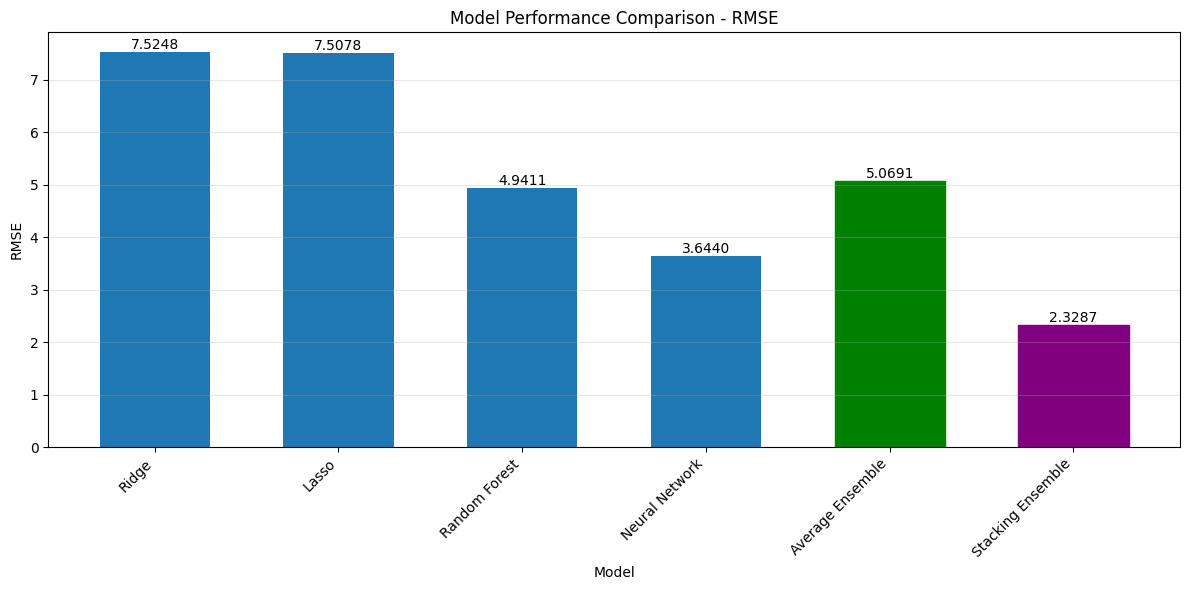

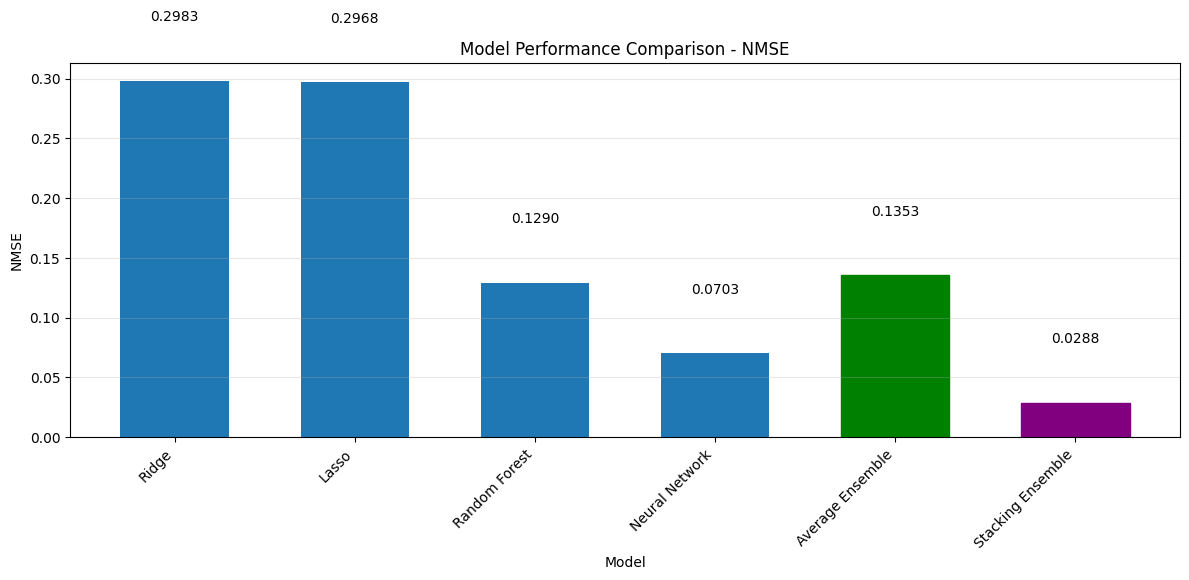

Ensemble comparison completed in 812.61 seconds

Step 8: Generating predictions for test data using best ensemble method...
Stacking ensemble performed better (RMSE: 2.3287 vs 5.0691)

Training final models on all data...
Training final Ridge model...
Training final Lasso model...
Training final Random Forest model...
Training final Neural Network model...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100 - Train Loss: 456.1994
Epoch 2/100 - Train Loss: 390.7647
Epoch 3/100 - Train Loss: 330.3518
Epoch 4/100 - Train Loss: 277.6625
Epoch 5/100 - Train Loss: 226.0312
Epoch 6/100 - Train Loss: 172.9396
Epoch 7/100 - Train Loss: 128.7292
Epoch 8/100 - Train Loss: 95.7246
Epoch 9/100 - Train Loss: 73.5875
Epoch 10/100 - Train Loss: 58.9485
Epoch 11/100 - Train Loss: 49.4533
Epoch 12/100 - Train Loss: 42.0619
Epoch 13/100 - Train Loss: 36.4467
Epoch 14/100 - Train Loss: 33.5191
Epoch 15/100 - Train Loss: 30.4682
Epoch 16/100 - Train Loss: 28.0072
Epoch 17/100 - Train Loss: 27.7235
Epoch 18/100 - Train Loss: 24.0149
Epoch 19/100 - Train Loss: 22.3294
Epoch 20/100 - Train Loss: 23.9542
Epoch 21/100 - Train Loss: 24.3667
Epoch 22/100 - Train Loss: 22.5939
Epoch 23/100 - Train Loss: 21.8505
Epoch 24/100 - Train Loss: 21.7055
Epoch 25/100 - Train Loss: 21.5230
Epoch 26/100 - Train Loss: 20.8273
Epoch 27/100 - Train Loss: 20.2423
Epoch 28/100 - Train Loss: 20.7484
Epoch 29/100 - Train L

In [ ]:
##ENSEMBLE STRATEGIES PIPELINE
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Main pipeline for ensemble strategies approach
if __name__ == "__main__":
    # Settings
    window_size = 500
    overlap_percent = 50
    apply_filtering = True  # Apply signal filtering
    normalize = True  # Define normalization setting
    
    print("Processing guided gestures dataset using Ensemble Strategies...")
    
    # Check if data is loaded
    if 'guided_X' not in globals() or 'guided_y' not in globals():
        print("Error: guided_X or guided_y not defined")
        print("Please load the datasets first:")
        print("guided_X = np.load('guided_dataset_X.npy')")
        print("guided_y = np.load('guided_dataset_y.npy')")
    else:
        # 1. If filtering is enabled, apply it to the raw EMG data
        if apply_filtering:
            print("\nStep 1: Applying signal filtering...")
            start_time = time.time()
            
            # Use preprocess_emg_data instead of recommended_emg_filter
            filtered_X = preprocess_emg_data(
                guided_X, 
                apply_filtering=True,
                normalize=normalize,
                visualize=False
            )
            print(f"Filtering completed in {time.time() - start_time:.2f} seconds")
            
            # Use the filtered data for further processing
            data_to_use = filtered_X
        else:
            # Use raw data if filtering is disabled
            data_to_use = guided_X
        
        # 2. Create windows with overlap
        print("\nStep 2: Creating windows with overlap...")
        start_time = time.time()
        X_windows, y_windows, window_indices = create_matching_windows(
            data_to_use, guided_y, window_size=window_size, overlap_percent=overlap_percent
        )
        print(f"Window creation completed in {time.time() - start_time:.2f} seconds")
        print(f"Created {len(window_indices)} windows with {overlap_percent}% overlap")
        print(f"X_windows shape: {X_windows.shape}")
        print(f"y_windows shape: {y_windows.shape}")
        
        # 3. Calculate mean joint angle in each window as the target
        y_targets = np.mean(y_windows, axis=2)
        print(f"Target values shape: {y_targets.shape}")
        
        # 4. Extract features
        print("\nStep 4: Extracting features...")
        feature_extractor = EMGFeatureExtractor()  # Using all features
        X_features = feature_extractor.transform(X_windows)
        feature_names = feature_extractor.get_feature_names()
        print(f"Extracted features shape: {X_features.shape}")
        print(f"Number of features: {len(feature_names)}")
        
        # 5. Define the base models for ensemble
        print("\nStep 5: Setting up base models...")
        base_models = [
            Pipeline([
                ('scaler', StandardScaler()),
                ('regressor', Ridge(alpha=1.0))
            ]),
            Pipeline([
                ('scaler', StandardScaler()),
                ('regressor', Lasso(alpha=0.01, max_iter=10000))
            ]),
            Pipeline([
                ('scaler', StandardScaler()),
                ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
            ])
        ]
        
        model_names = ['Ridge', 'Lasso', 'Random Forest']
        
        # 6. Initialize neural network if PyTorch is available
        neural_net = None
        try:
            import torch
            import torch.nn as nn
            
            # Neural Network architecture is already defined in the previous cells,
            # so we'll just set a flag to include it in the ensemble
            print("PyTorch is available. Including Neural Network in the ensemble.")
            neural_net = True
        except ImportError:
            print("PyTorch is not available. Neural Network will not be included in the ensemble.")
        
        # 7. Perform ensemble comparison
        print("\nStep 7: Comparing ensemble strategies...")
        start_time = time.time()
        ensemble_results = compare_ensemble_strategies(
            X_windows, y_targets, window_indices,
            n_sessions=guided_X.shape[0],
            base_models=base_models,
            model_names=model_names,
            neural_net=neural_net
        )
        print(f"Ensemble comparison completed in {time.time() - start_time:.2f} seconds")
        
        # 8. Generate predictions for test data if available
        if 'guided_testset_X' in globals():
            print("\nStep 8: Generating predictions for test data using best ensemble method...")
            start_time = time.time()
            
            # Determine which ensemble method performed better
            avg_rmse = ensemble_results['ensemble_avg']['avg_rmse']
            stack_rmse = ensemble_results['ensemble_stack']['avg_rmse']
            
            if stack_rmse < avg_rmse:
                best_ensemble = "Stacking"
                print(f"Stacking ensemble performed better (RMSE: {stack_rmse:.4f} vs {avg_rmse:.4f})")
            else:
                best_ensemble = "Average"
                print(f"Average ensemble performed better (RMSE: {avg_rmse:.4f} vs {stack_rmse:.4f})")
            
            # Process test data
            n_sessions, n_windows, n_electrodes, window_size = guided_testset_X.shape
            batch_size = 50  # Process in batches for speed
            
            # Initialize array for storing base model predictions
            all_model_predictions = []
            
            # Train final models on entire dataset
            print("\nTraining final models on all data...")
            
            # Train all base models
            for i, (model, name) in enumerate(zip(base_models, model_names)):
                print(f"Training final {name} model...")
                model.fit(X_features, y_targets)
            
            # Train neural network if available
            nn_model = None
            if neural_net:
                print("Training final Neural Network model...")
                from sklearn.preprocessing import StandardScaler
                import torch
                
                # Standardize features
                scaler = StandardScaler()
                X_scaled = scaler.fit_transform(X_features)
                
                # Train neural network
                device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
                nn_model, _ = train_neural_network(
                    X_scaled, y_targets,
                    input_size=X_scaled.shape[1],
                    output_size=y_targets.shape[1],
                    device=device,
                    early_stopping=False  # Use all epochs for final model
                )
            
            # Process test data in batches
            print("\nProcessing test data...")
            test_predictions_list = [np.zeros((n_sessions * n_windows, y_targets.shape[1])) for _ in range(len(base_models) + (1 if neural_net else 0))]
            current_idx = 0
            
            for session in range(n_sessions):
                print(f"Processing session {session+1}/{n_sessions}...")
                
                for batch_start in range(0, n_windows, batch_size):
                    batch_end = min(batch_start + batch_size, n_windows)
                    batch_size_actual = batch_end - batch_start
                    
                    # Prepare batch data
                    batch_windows = guided_testset_X[session, batch_start:batch_end]
                    batch_windows_reshaped = batch_windows.reshape(batch_size_actual, n_electrodes, window_size)
                    
                    # Apply filtering if needed
                    if apply_filtering:
                        # Use preprocess_emg_data instead of recommended_emg_filter
                        batch_windows_processed = preprocess_emg_data(
                            batch_windows_reshaped, 
                            apply_filtering=True,
                            normalize=normalize,
                            visualize=False
                        )
                        batch_windows_reshaped = batch_windows_processed
                    
                    # Extract features
                    batch_features = feature_extractor.transform(batch_windows_reshaped)
                    
                    # Generate predictions from each base model
                    for i, model in enumerate(base_models):
                        batch_predictions = model.predict(batch_features)
                        for j in range(batch_size_actual):
                            test_predictions_list[i][current_idx + j] = batch_predictions[j]
                    
                    # Generate predictions from neural network if available
                    if neural_net:
                        # Standardize features using the same scaler
                        batch_features_scaled = scaler.transform(batch_features)
                        
                        # Convert to PyTorch tensor
                        batch_tensor = torch.FloatTensor(batch_features_scaled).to(device)
                        
                        # Generate predictions
                        nn_model.eval()
                        with torch.no_grad():
                            batch_predictions_nn = nn_model(batch_tensor).cpu().numpy()
                        
                        for j in range(batch_size_actual):
                            test_predictions_list[-1][current_idx + j] = batch_predictions_nn[j]
                    
                    current_idx += batch_size_actual
                    
                    # Progress update
                    if batch_end % (batch_size * 2) == 0 or batch_end == n_windows:
                        percent_done = (current_idx / (n_sessions * n_windows)) * 100
                        print(f"  Processed {current_idx}/{n_sessions * n_windows} windows ({percent_done:.1f}%)")
            
            # Generate ensemble predictions
            if best_ensemble == "Average":
                print("\nGenerating Average Ensemble predictions...")
                ensemble_predictions = ensemble_averaging(test_predictions_list)
            else:  # Stacking
                print("\nGenerating Stacking Ensemble predictions...")
                # Since we can't properly train a meta-learner without ground truth for test data,
                # we'll reuse the weights from cross-validation
                # Create a simple meta-learner that applies the average weights learned during CV
                ensemble_predictions = np.zeros_like(test_predictions_list[0])
                
                # Use equal weights as a fallback
                weights = np.ones(len(test_predictions_list)) / len(test_predictions_list)
                ensemble_predictions = ensemble_averaging(test_predictions_list, weights)
            
            print(f"Generated ensemble predictions shape: {ensemble_predictions.shape}")
            print(f"Prediction completed in {time.time() - start_time:.2f} seconds")
            
            # Save predictions to CSV
            print("\nSaving ensemble predictions to ensemble_predictions.csv...")
            np.savetxt('ensemble_predictions.csv', ensemble_predictions, delimiter=',')
            print("Predictions saved successfully!")
        else:
            print("\nTest data not found. If you have the test data, please load it with:")
            print("guided_testset_X = np.load('guided_testset_X.npy')")